**Twitter Posts ML and DL Analysis for Binary Classification**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/Diplomatiki/Twitter_Dataset_ML_Analysis

/content/drive/MyDrive/Diplomatiki/Twitter_Dataset_ML_Analysis


In [4]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 6.3 MB/s eta 0:00:00


In [5]:
pip install emosent-py

In [6]:
pip install NRCLex

INFO: pip is looking at multiple versions of nrclex to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for NRCLex: filename=NRCLex-3.0.0-py3-none-any.whl size=43309 sha256=848e21f5c1145cb3448b22590225bcf2c084272e52e512b1148c63ad5ff2a12d
  Stored in directory: /root/.cache/pip/wheels/d2/10/44/6abfb1234298806a145fd6bcaec8cbc712e88dd1cd6cb242fa
Successfully built NRCLex


In [7]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 4.9 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import nltk, re
from nrclex import NRCLex
import contractions
import emoji
from emosent import get_emoji_sentiment_rank
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, words
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tag import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import string
import random
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import SimpleRNN, Dense, LeakyReLU, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, Input, Flatten, Bidirectional, LSTM, Reshape
from keras.utils import plot_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from wordcloud import WordCloud

In [9]:
def draw_ROC_curves(X_test, y_test, models, title_extra=' Count Vectorizer'):

  plt.figure()

  for name, model in models.items():

    X_test2 = X_test

    print("model = ", name)

    if "Neural Network" in name:
      if "Dense" not in name:
        X_test2 = np.array(X_test2)

        if ("Hybrid" not in name) and ("CNN" not in name):
          X_test2 = X_test2.reshape(X_test2.shape[0], X_test2.shape[1])
        else:
          X_test2 = X_test2.reshape((X_test2.shape[0], X_test2.shape[1], 1))

      else:
        X_test2 = np.array(X_test2)
        X_test2 = X_test2.reshape(X_test2.shape[0], -1)

      y_pred = model.predict(X_test2)
    else:
      y_pred = model.predict_proba(X_test)[:, 1]


    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label='%s (AUC = %0.2f)' % (name, roc_auc))


  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC)' + title_extra)
  plt.legend(loc="lower right", bbox_to_anchor=(1.0, 0.0), fontsize='x-small')
  plt.show()

  return

In [84]:
def draw_ROC_curves_with_FastText(X_test, y_test, models, fpr_fasttext, tpr_fasttext, fasttext_auc):

  plt.figure()

  for name, model in models.items():

    X_test2 = X_test

    print("model = ", name)

    if "Neural Network" in name:
      if "Dense" not in name:
        X_test2 = np.array(X_test2)

        if ("Hybrid" not in name) and ("CNN" not in name):
          X_test2 = X_test2.reshape(X_test2.shape[0], X_test2.shape[1])
        else:
          X_test2 = X_test2.reshape((X_test2.shape[0], X_test2.shape[1], 1))

      else:
        X_test2 = np.array(X_test2)
        X_test2 = X_test2.reshape(X_test2.shape[0], -1)

      y_pred = model.predict(X_test2)
    else:
      y_pred = model.predict_proba(X_test)[:, 1]


    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label='%s (AUC = %0.2f)' % (name, roc_auc))


  plt.plot(fpr_fasttext, tpr_fasttext, lw=2, label='%s (AUC = %0.2f)' % ('FastText', fasttext_auc))
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Of Machine Learning Models')
  plt.legend(loc="lower right", bbox_to_anchor=(1.0, 0.0), fontsize='x-small')
  plt.show()

  return

In [11]:
def print_confusion_matrix(y_test, y_pred):
  # Assuming y_test and y_pred are your true labels and predicted labels respectively
  conf_matrix = confusion_matrix(y_test, y_pred)

  # Extracting values from confusion matrix
  TN, FP, FN, TP = conf_matrix.ravel()

  print("True Positives:", TP)
  print("True Negatives:", TN)
  print("False Positives:", FP)
  print("False Negatives:", FN)

  return

In [12]:
def calculate_evaluation_metrics(y_pred, y_test):

  # Calculate accuracy
  accuracy = accuracy_score(y_test, y_pred)
  accuracy *= 100
  print("Accuracy: ", accuracy, "%")

  # Calculate precision
  precision = precision_score(y_test, y_pred)
  precision *= 100
  print("Precision:", precision, "%")

  # Calculate recall (sensitivity)
  recall = recall_score(y_test, y_pred)
  recall *= 100
  print("Recall (Sensitivity):", recall, "%")

  # Calculate specificity
  conf_matrix = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = conf_matrix.ravel()
  specificity = tn / (tn + fp)
  specificity *= 100
  print("Specificity:", specificity, "%")

  # Calculate F1-score
  f1 = f1_score(y_test, y_pred)
  f1 *= 100
  print("F1-score:", f1, "%")

  return accuracy, precision, recall, specificity, f1

In [ ]:
df = pd.read_csv("Mental-Health-Twitter.csv").drop('Unnamed: 0', axis=1)
df

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
19995,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,A day without sunshine is like night.,1169875706,442,230,7,1063601,0,0
19996,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,"Boren's Laws: (1) When in charge, ponder. (2) ...",1169875706,442,230,7,1063601,0,0
19997,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,The flow chart is a most thoroughly oversold p...,1169875706,442,230,7,1063601,0,0
19998,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,"Ships are safe in harbor, but they were never ...",1169875706,442,230,7,1063601,0,0


In [ ]:
unique_users_count = df['user_id'].nunique()
print("Number of unique users:", unique_users_count)

Number of unique users: 72


In [ ]:
unique_posts_count = df['post_id'].nunique()
print("Number of posts:", unique_posts_count)

Number of posts: 19881


In [ ]:
print(df['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


In [ ]:
print('\n'.join(df['post_text'].to_list()))

It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.
It's Sunday, I need a break, so I'm planning to spend as little time as possible on the #A14...
Awake but tired. I need to sleep but my brain has other ideas...
RT @SewHQ: #Retro bears make perfect gifts and are great for beginners too! Get stitching with October's Sew on sale NOW! #yay http://t.co/…
It’s hard to say whether packing lists are making life easier or just reinforcing how much still needs doing... #movinghouse #anxiety
Making packing lists is my new hobby... #movinghouse
At what point does keeping stuff for nostalgic reasons cross the line into plain old hoarding...? #movinghouse
Currently in the finding-boxes-of-random-shit packing phase. I think I’m a closet hoarder...
Can't be bothered to cook, take away on the way 😁👍🏼 #lazy
RT @itventsnews: ITV releases promo video for the final series of Downton Abbey http://t.co/mC8Ive72zR http:

In [ ]:
def remove_stopwords(text):

  text2 = re.sub(r'[^\w\s]', '', text) # Remove punctuations
  word_list = text2.split() # Tokenize the tweet

  stop_words = set(stopwords.words('english'))

  filtered_words = []
  for word in word_list:
    if word not in stop_words:
      filtered_words.append(word)

  final_text = ' '.join(filtered_words)

  return final_text.strip()

In [ ]:
def lemmatize_text(text):

  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word.lower() not in stopwords.words('english')]

  tagged_tokens = pos_tag(tokens) # Part of speech tagging
  lemmatizer = WordNetLemmatizer() # Initialize lemmatizer

  lemmatized_tokens = []
  for token, tag in tagged_tokens:
    if tag.startswith('NN'):  # noun
      lemmatized_token = lemmatizer.lemmatize(token, pos='n')
    elif tag.startswith('VB'):  # verb
      lemmatized_token = lemmatizer.lemmatize(token, pos='v')
    elif tag.startswith('JJ'):  # adjective
      lemmatized_token = lemmatizer.lemmatize(token, pos='a')
    elif tag.startswith('R'):  # adverb
      lemmatized_token = lemmatizer.lemmatize(token, pos='r')
    else:
      lemmatized_token = token  # default to original token
    lemmatized_tokens.append(lemmatized_token)

  final_text = ' '.join(lemmatized_tokens)

  return final_text.strip()

In [ ]:
def stem_text(text):

  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word.lower() not in stopwords.words('english')]

  porter_stemmer = PorterStemmer()
  stemmed_words = []

  for token in tokens:
    if len(token) > 3:
      stemmed_words.append(porter_stemmer.stem(token))

  final_text = ' '.join(stemmed_words)

  return final_text.strip()

In [ ]:
def split_words(post, word_list, word_pattern):

  def replace(match):
    return f" {match.group(0)} "

  result = re.sub(word_pattern, replace, post)
  result = result.split()

  split_words = []
  for word in result:
    if len(word) > 0:
      split_words.append(word)

  final_text = ' '.join(split_words)

  return final_text.strip()

In [ ]:
def text_preprocessing(post_id_list, posts_list):

  nltk.download('punkt')
  nltk.download('stopwords')
  nltk.download('averaged_perceptron_tagger')
  nltk.download('wordnet')
  nltk.download('words')

  word_list = set(words.words())
  word_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(word) for word in sorted(word_list, key=len, reverse=True)) + r')\b')

  processed_posts = pd.DataFrame(columns=['post_id', 'post_text'])

  #final_text_list = []
  for id, post in zip(post_id_list, posts_list):
    post = post.lower() # Lowercase
    post = post.strip() # Remove leading/trailing whitespace
    post = re.compile(r'https?://\S+|www\.\S+').sub(r'', post) # Remove URLs
    post = re.sub('\s+', ' ', post) # Remove extra space and tabs

    ################################
    post = emoji.replace_emoji(post, replace='') # Remove Emojis
    post = re.sub('[^a-zA-Z]',' ',post)
    ################################

    post = re.sub(r'@[A-Za-z0-9_]+', '', post) # Remove @mentions
    post = re.sub(r'#([^\s]+)', '', post) # Remove hashtags

    post = re.sub(r'[^\w\s]', '', post) # Remove special symbols and punctuation
    post = re.sub(r'\d+', '', post) # Remove numbers

    post = contractions.fix(post) # Expand contractions

    #pattern = r'([a-zA-Z])([A-Z])' # Define a pattern to identify joint words
    #post = re.sub(pattern, r'\1 \2', post) # Split joint words

    post = split_words(post, word_list, word_pattern)

    post = remove_stopwords(post) # Remove stopwords

    post = lemmatize_text(post) # Lemmatize text

    ############################################################
    post = stem_text(post)
    ############################################################

    #final_text_list.append(post)

    new_entry = pd.DataFrame({'post_id': [id], 'post_text': [post]})

    processed_posts = pd.concat([processed_posts, new_entry], ignore_index=True)

  return processed_posts

In [ ]:
processed_posts = text_preprocessing(df['post_id'].to_list(), df['post_text'].to_list())
processed_posts

In [ ]:
df_processed = df.drop("post_text", axis=1)
df_processed = pd.merge(df_processed, processed_posts, on='post_id', how='inner')
column = df_processed.pop('post_text')
df_processed.insert(df_processed.columns.get_loc('post_created') + 1, column.name, column)

df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed.to_csv('Mental-Health-Twitter-Processed.csv', index=False)

In [ ]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
print(df_processed['post_id'].nunique())

19881


In [ ]:
print(df_processed['label'].value_counts())

label
1    9942
0    9939
Name: count, dtype: int64


In [ ]:
df_processed = df_processed.drop('post_created', axis=1)
df_processed

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
print(df_processed.isnull().sum())

post_id        0
post_text     86
user_id        0
followers      0
friends        0
favourites     0
statuses       0
retweets       0
label          0
dtype: int64


In [ ]:
df_processed = df_processed.dropna()
print(df_processed.isnull().sum())

post_id       0
post_text     0
user_id       0
followers     0
friends       0
favourites    0
statuses      0
retweets      0
label         0
dtype: int64


In [ ]:
print(df_processed['label'].value_counts())

label
0    9904
1    9891
Name: count, dtype: int64


In [ ]:
# Combine all strings into a single text
all_text = ' '.join(df_processed['post_text'])

# Split the text into individual words
words = all_text.split()
print("Word count: ", len(set(words)))

Word count:  16869


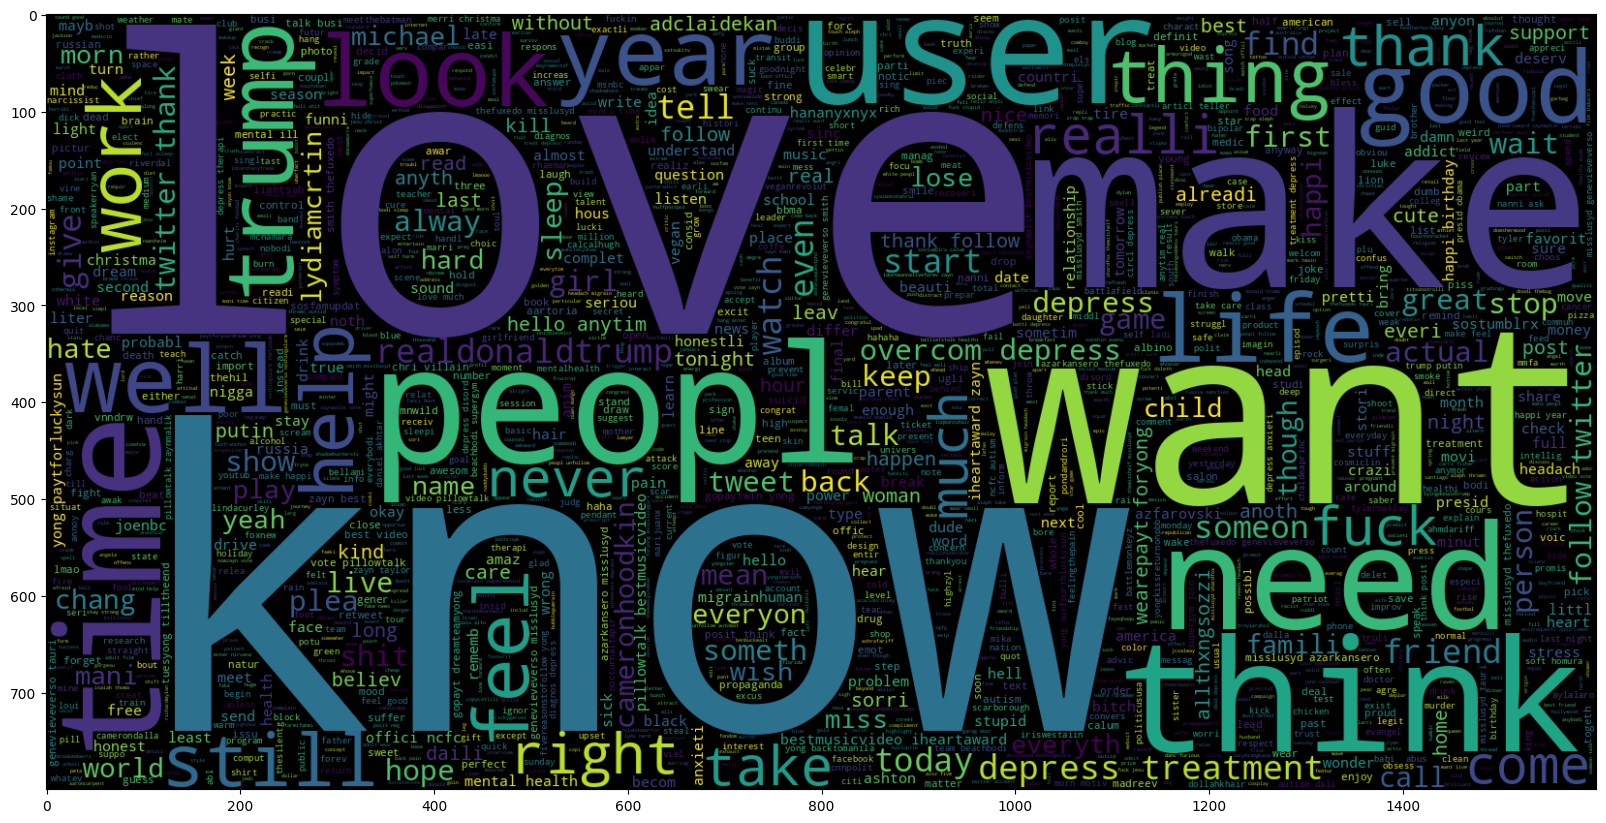

In [ ]:
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 10000 , width = 1600 , height = 800).generate(" ".join(df_processed.post_text))
plt.imshow(wc , interpolation = 'bilinear')

In [ ]:
df_depressed = df_processed[df_processed['label'] == 1]
df_depressed

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...
10111,587768995559772160,cslewisu agre forgiv beauti idea practic cslewi,2766067037,78,175,664,1148,217,1
10112,587719358522101760,believ year blastyblast wlmhk picstitch,2766067037,78,175,664,1148,0,1
10113,587715060790734848,year journey begin never know challeng would c...,2766067037,78,175,664,1148,0,1
10114,587065862944874497,find hammock friend park today start young sar...,2766067037,78,175,664,1148,0,1


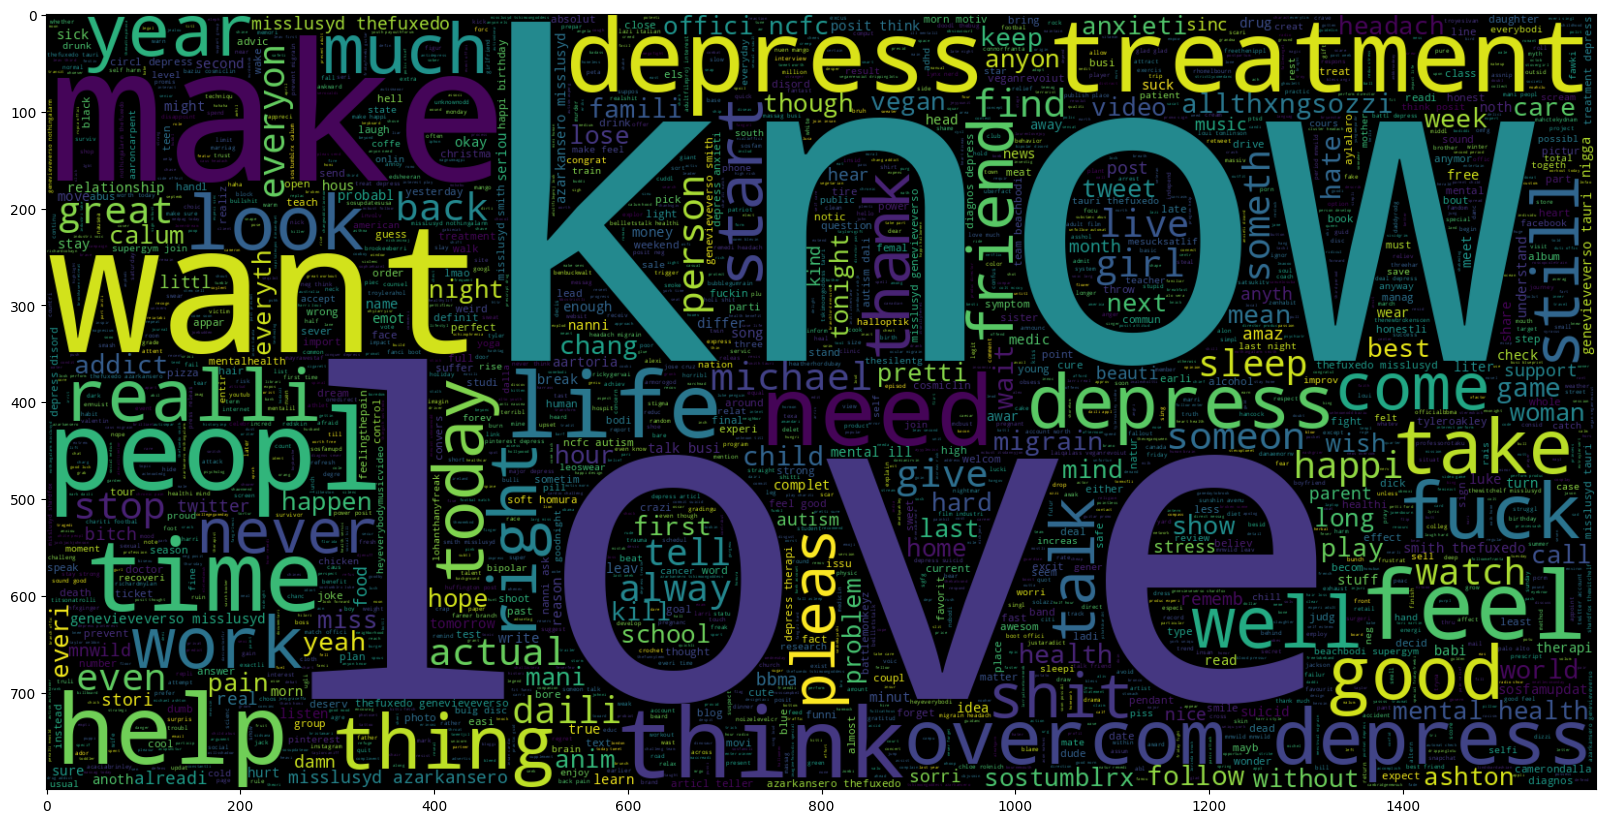

In [ ]:
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 10000 , width = 1600 , height = 800).generate(" ".join(df_depressed.post_text))
plt.imshow(wc , interpolation = 'bilinear')

In [ ]:
df_not_depressed = df_processed[df_processed['label'] == 0]
df_not_depressed

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
10116,819457334271279105,enemi invis know fight,727820220291645442,123,145,1068,23801,0,0
10117,818505546424647680,burn hous ugli brack,727820220291645442,123,145,1068,23801,0,0
10118,818025680071847937,cocoa counterattack,727820220291645442,123,145,1068,23801,0,0
10119,817341868459466753,noob asp golden,727820220291645442,123,145,1068,23801,0,0
10120,817338550102302720,drow,727820220291645442,123,145,1068,23801,0,0
...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


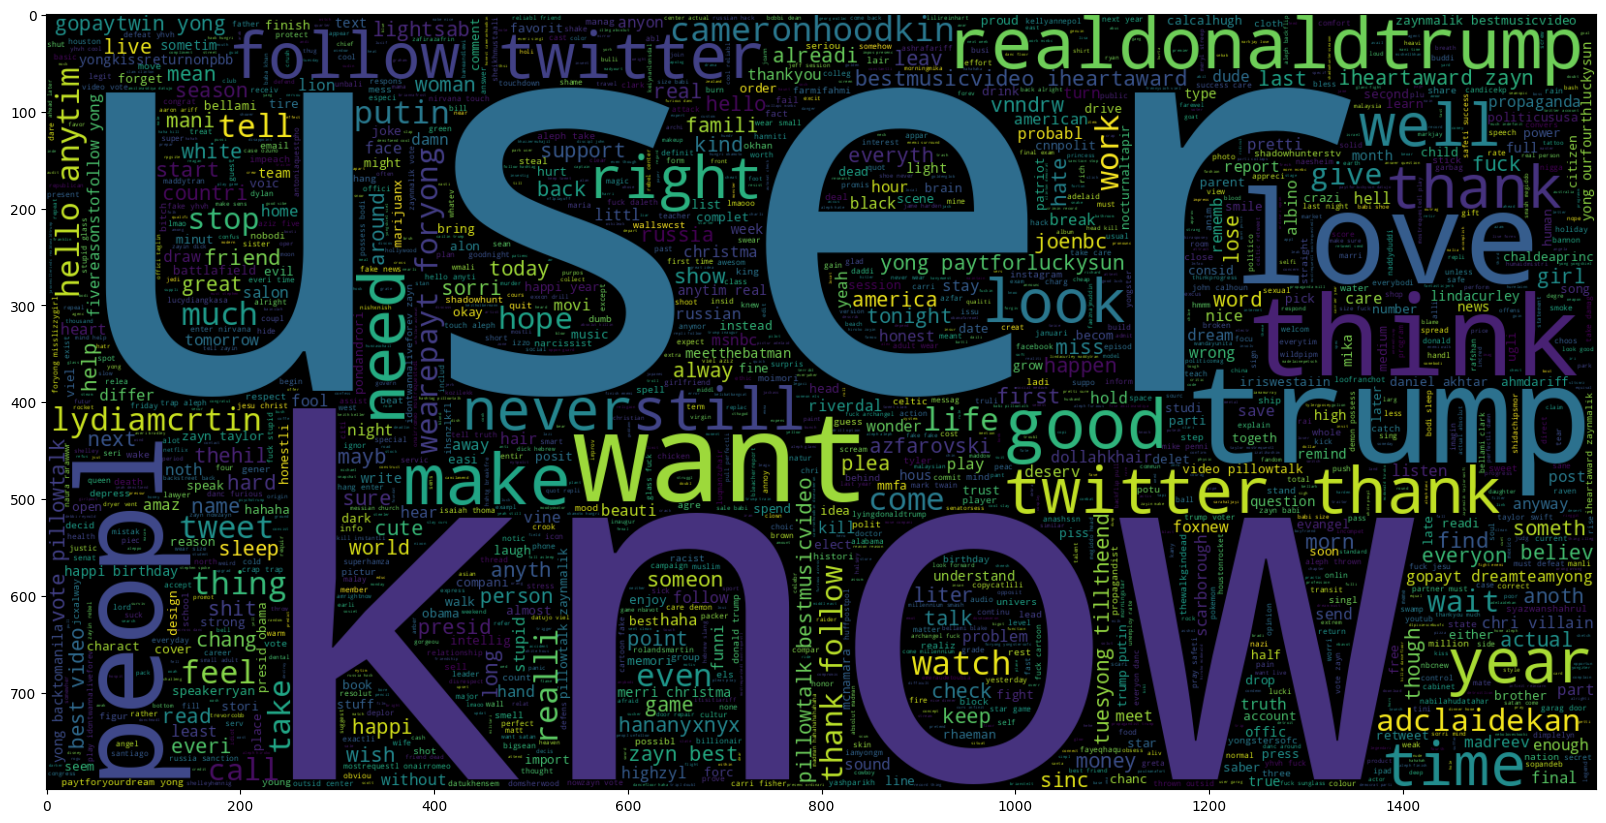

In [ ]:
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 10000 , width = 1600 , height = 800).generate(" ".join(df_not_depressed.post_text))
plt.imshow(wc , interpolation = 'bilinear')

##STA PARAKATW AN GIA DF_PROCESSED ANTI GIA DF_GROUPED

###CountVectorizer

In [ ]:
# Initialize CountVectorizer
vectorizer = CountVectorizer(max_features=5000)

# Fit the vectorizer to the data and transform the tweets into a bag of words representation
bow_matrix = vectorizer.fit_transform(df_processed['post_text'].to_list())

# Get the list of feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Print the bag of words matrix
print("Bag of Words Matrix:")
print(bow_matrix.toarray())

Bag of Words Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print(np.all(bow_matrix.toarray() == 0))

False


In [ ]:
print(bow_matrix.count_nonzero() / (bow_matrix.shape[0] * bow_matrix.shape[1]))

0.0009786208638545087


In [ ]:
print((bow_matrix.shape[0] * bow_matrix.shape[1]))
print(bow_matrix.shape[0] , bow_matrix.shape[1])
print(bow_matrix.size)

98975000
19795 5000
96859


In [ ]:
df_processed['post_text'] = list(bow_matrix.toarray())
df_processed

<ipython-input-31-24bf19c1facf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['post_text'] = list(bow_matrix.toarray())


,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1013187241,84,211,251,837,0,1
1,637890384576778240,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1013187241,84,211,251,837,1,1
2,637749345908051968,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1013187241,84,211,251,837,0,1
3,637696421077123073,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1013187241,84,211,251,837,2,1
4,637696327485366272,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1169875706,442,230,7,1063601,0,0
20234,819334654260080640,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1169875706,442,230,7,1063601,0,0
20235,819334503042871297,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1169875706,442,230,7,1063601,0,0
20236,819334419374899200,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id'], axis=1)
df_processed

,post_id,post_text,label
0,637894677824413696,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
1,637890384576778240,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
2,637749345908051968,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
3,637696421077123073,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
4,637696327485366272,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
...,...,...,...
20233,819336825231773698,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
20234,819334654260080640,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
20235,819334503042871297,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
20236,819334419374899200,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0


In [ ]:
# Print the feature names
print("\nFeature Names:")
print(feature_names)
print(len(feature_names))
#for f in feature_names:
  #print(f)


Feature Names:
['aaron' 'aaroncarpent' 'aartoria' ... 'zone' 'zquad' 'zurab']
5000


In [ ]:
print('is_depressed' in feature_names)

False


In [ ]:
df_post_text_final = pd.DataFrame(df_processed['post_text'].to_list(), columns=feature_names)

df_post_text_final['post_id'] = df_processed['post_id']
df_post_text_final

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,post_id
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.378947e+17
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.378904e+17
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.377493e+17
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.376964e+17
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.376963e+17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.104918e+17
19791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.104840e+17
19792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.104834e+17
19793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.104833e+17


In [ ]:
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
print(df_processed.isnull().sum())

post_id         0
post_text       0
is_depressed    0
dtype: int64


In [ ]:
df_processed.to_csv('Final-Tweets-Processed-Small.csv', index=False)

In [ ]:
df_processed = pd.read_csv('Final-Tweets-Processed-Small.csv')
df_processed

,post_id,post_text,is_depressed
0,637894677824413696,[0 0 0 ... 0 0 0],1
1,637890384576778240,[0 0 0 ... 0 0 0],1
2,637749345908051968,[0 0 0 ... 0 0 0],1
3,637696421077123073,[0 0 0 ... 0 0 0],1
4,637696327485366272,[0 0 0 ... 0 0 0],1
...,...,...,...
19790,819336825231773698,[0 0 0 ... 0 0 0],0
19791,819334654260080640,[0 0 0 ... 0 0 0],0
19792,819334503042871297,[0 0 0 ... 0 0 0],0
19793,819334419374899200,[0 0 0 ... 0 0 0],0


In [ ]:
#NEW CODE
df_processed = df_processed.sort_values(by='post_id', ascending=False).reset_index()
df_processed = df_processed.drop('index', axis=1)

df_post_text_final = df_post_text_final.sort_values(by='post_id', ascending=False).reset_index()
df_post_text_final = df_post_text_final.drop('index', axis=1)

df_post_text_final['is_depressed'] = df_processed['is_depressed']
df_processed = df_post_text_final.drop('post_id', axis=1)
df_processed = df_processed.drop('level_0', axis=1)
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,is_depressed
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
print(df_processed['is_depressed'].value_counts())

is_depressed
0    9904
1    9891
Name: count, dtype: int64


In [ ]:
df_processed.to_csv('Final-Tweets-Processed-CountVectorized-Small.csv', index=False)

In [ ]:
df_processed = pd.read_csv("Final-Tweets-Processed-CountVectorized-Small.csv")
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,is_depressed
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X = df_processed.drop('is_depressed', axis=1)
y = df_processed['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##FastText – Text Classifier

In [13]:
pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp310-cp310-linux_x86_64.whl size=4296185 sha256=936c69f7b9905f6479335e953051fc6422c2aacaf662d83434eae5e699576c16
  Stored in directory: /root/.cache/pip/wheels/0d/a2/00/81db54d3e6a8199b829d58e02cec2ddb20ce3e59fad8d3c92a
Successfully built fasttext


In [14]:
pip install --upgrade fasttext

In [35]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed = df_processed.dropna()
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [36]:
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id', 'post_created', 'post_id'], axis=1)
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
df_processed

,post_text,is_depressed
0,year sinc diagnos anxieti depress today take m...,1
1,sunday need break plan spend littl time possibl,1
2,awak tire need sleep brain idea,1
3,sewhq retro bear make perfect gift great begin...,1
4,hard whether pack list make life easi reinforc...,1
...,...,...
20233,without sunshin like night,0
20234,boren charg ponder troubl deleg doubt mumbl,0
20235,flow chart thoroughli oversold piec program do...,0
20236,ship safe harbor never mean stay,0


In [37]:
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
print(df_processed.isnull().sum())

post_text       0
is_depressed    0
dtype: int64


In [38]:
# Split into training and test sets
train_data = df_processed.sample(frac=0.8, random_state=42)
test_data = df_processed.drop(train_data.index)

In [39]:
# Save training data
with open('train_data.txt', 'w') as f:
    for row in train_data.itertuples():
        label = '__label__positive' if row.is_depressed == 1 else '__label__negative'
        f.write(f"{label} {row.post_text}\n")

In [40]:
# Save test data
with open('test_data.txt', 'w') as f:
    for row in test_data.itertuples():
        label = '__label__positive' if row.is_depressed == 1 else '__label__negative'
        f.write(f"{label} {row.post_text}\n")

In [41]:
import fasttext

# Train the classifier
model = fasttext.train_supervised('train_data.txt', epoch=100, lr=0.5, wordNgrams=2, verbose=2, minCount=1)

# Save the model
model.save_model('model.bin')

In [42]:
# Load the model
model = fasttext.load_model('model.bin')

# Test the classifier
nexamples, precision, recall = model.test('test_data.txt')
accuracy = precision

In [43]:
print("Accuracy: ", accuracy*100, "%")
print("Precision: ", precision*100, "%")
print("Recall: ", recall*100, "%")
print("Number of examples: ", nexamples)

Accuracy:  84.11214953271028 %
Precision:  84.11214953271028 %
Recall:  84.11214953271028 %
Number of examples:  3959


In [44]:
# Get texts and true labels
posts = test_data['post_text'].tolist()
true_labels = test_data['is_depressed'].tolist()

tn=0
fp=0

# Get predicted probabilities
predicted_probabilities = []
for true_label, post in zip(true_labels, posts):
    labels, probabilities = model.predict(post, k=-1)  # k=-1 to get all labels
    if '__label__positive' in labels:
        index = labels.index('__label__positive')
        probability = probabilities[index]
    else:
        probability = 0


    if probabilities[0] > probabilities[1]:
      pred_label = labels[0]

    else:
      pred_label = labels[1]

    if pred_label == '__label__negative' and true_label == 0:
      tn = tn + 1
    elif pred_label == '__label__positive' and true_label == 0:
      fp = fp + 1

    predicted_probabilities.append(probability)

# Calculate AUC score
fasttext_auc = roc_auc_score(true_labels, predicted_probabilities)
if (tn + fp) > 0:
  specificity = tn / (tn + fp)
else:
  specificity = 0


print("AUC = ", fasttext_auc)
print("Specificity = ", specificity*100, " %")

AUC =  0.9304402240294158
Specificity =  84.15741675075681  %


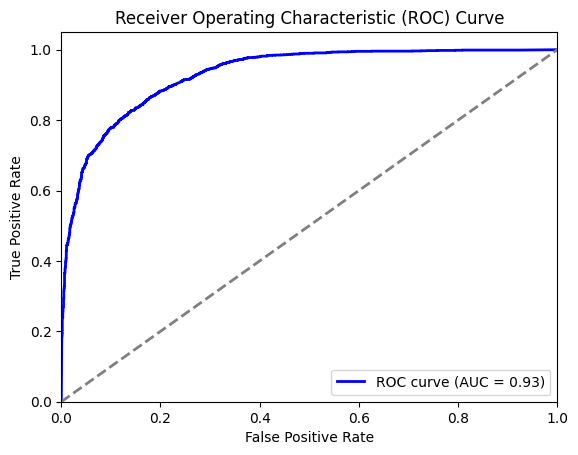

In [45]:
# Calculate ROC curve
fpr_fasttext, tpr_fasttext, thresholds = roc_curve(true_labels, predicted_probabilities)
fasttext_auc = roc_auc_score(true_labels, predicted_probabilities)

# Plot ROC curve
plt.figure()
plt.plot(fpr_fasttext, tpr_fasttext, color='blue', lw=2, label=f'ROC curve (AUC = {fasttext_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

##ML Classification Models/CountVectorizer

###Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  77.14069209396312 %
Precision: 71.58060701616083 %
Recall (Sensitivity): 90.8 %
Specificity: 63.1955079122001 %
F1-score: 80.05289839100728 %
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      1959
           1       0.72      0.91      0.80      2000

    accuracy                           0.77      3959
   macro avg       0.79      0.77      0.77      3959
weighted avg       0.79      0.77      0.77      3959

True Positives: 1816
True Negatives: 1238
False Positives: 721
False Negatives: 184


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.7699775395610005


###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  75.80197019449356 %
Precision: 75.58939096267191 %
Recall (Sensitivity): 76.95 %
Specificity: 74.62991322103115 %
F1-score: 76.26362735381565 %
              precision    recall  f1-score   support

           0       0.76      0.75      0.75      1959
           1       0.76      0.77      0.76      2000

    accuracy                           0.76      3959
   macro avg       0.76      0.76      0.76      3959
weighted avg       0.76      0.76      0.76      3959

True Positives: 1539
True Negatives: 1462
False Positives: 497
False Negatives: 461


In [ ]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.7578995661051557


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.30260166708764 %
Precision: 76.84705882352941 %
Recall (Sensitivity): 81.65 %
Specificity: 74.88514548238896 %
F1-score: 79.17575757575757 %
              precision    recall  f1-score   support

           0       0.80      0.75      0.77      1959
           1       0.77      0.82      0.79      2000

    accuracy                           0.78      3959
   macro avg       0.78      0.78      0.78      3959
weighted avg       0.78      0.78      0.78      3959

True Positives: 1633
True Negatives: 1467
False Positives: 492
False Negatives: 367


In [ ]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.7826757274119449


###Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.40363728214196 %
Precision: 78.10505645557193 %
Recall (Sensitivity): 79.55 %
Specificity: 77.23328228688106 %
F1-score: 78.82090661382215 %
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1959
           1       0.78      0.80      0.79      2000

    accuracy                           0.78      3959
   macro avg       0.78      0.78      0.78      3959
weighted avg       0.78      0.78      0.78      3959

True Positives: 1591
True Negatives: 1513
False Positives: 446
False Negatives: 409


In [ ]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.7839164114344055


###AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  68.57792371811064 %
Precision: 89.87341772151899 %
Recall (Sensitivity): 42.6 %
Specificity: 95.09954058192956 %
F1-score: 57.80189959294436 %
              precision    recall  f1-score   support

           0       0.62      0.95      0.75      1959
           1       0.90      0.43      0.58      2000

    accuracy                           0.69      3959
   macro avg       0.76      0.69      0.66      3959
weighted avg       0.76      0.69      0.66      3959

True Positives: 852
True Negatives: 1863
False Positives: 96
False Negatives: 1148


In [ ]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.6884977029096477


###Stochastic Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, subsample=0.8, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  76.00404142460218 %
Precision: 84.63060686015831 %
Recall (Sensitivity): 64.14999999999999 %
Specificity: 88.10617662072487 %
F1-score: 72.9806598407281 %
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      1959
           1       0.85      0.64      0.73      2000

    accuracy                           0.76      3959
   macro avg       0.78      0.76      0.76      3959
weighted avg       0.78      0.76      0.76      3959

True Positives: 1283
True Negatives: 1726
False Positives: 233
False Negatives: 717


In [ ]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.7612808831036243


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


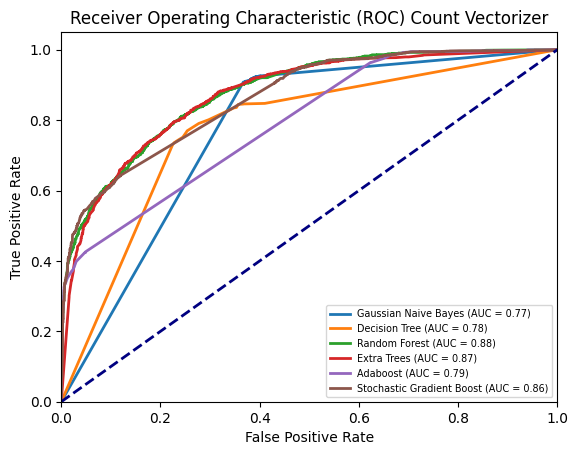

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models)

##TF-IDF Vectorizer

In [ ]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id', 'post_created'], axis=1)
df_processed = df_processed.dropna()
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed

,post_id,post_text,label
0,703265364491239424,also guilti conscienc forc feed pill twice sto...,1
1,810349546895187968,cameronhoodkin truli enlighten fuck tonight thank,0
2,809925992340856832,sheikhmustaali gadismaghribi pontian besar specif,0
3,817720777080377346,aleph furious danc around,0
4,590051680777072641,talk busi learningtolivewithnoshadowofdepress,1
...,...,...,...
19790,809666426223009793,drink,0
19791,816636648091852800,dodo littl foot sunburnt rescu,0
19792,578131546709880833,chariti today chariti footbal match offici ncf...,1
19793,814749930648522752,decid make lasagn tonight hungri bread moldi,0


In [ ]:
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
print(df_processed.isnull().sum())

post_id         0
post_text       0
is_depressed    0
dtype: int64


In [ ]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer to the data and transform the tweets into a TF-IDF representation
tfidf_matrix = tfidf_vectorizer.fit_transform(df_processed['post_text'].to_list())

# Get the list of feature names (words)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Print the TF-IDF matrix
print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

TF-IDF Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# Print the feature names
print("\nFeature Names:")
print(tfidf_feature_names)


Feature Names:
['aaron' 'aaroncarpent' 'aartoria' ... 'zone' 'zquad' 'zurab']


In [ ]:
df_processed['post_text'] = list(tfidf_matrix.toarray())
df_processed

,post_id,post_text,is_depressed
0,703265364491239424,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
1,810349546895187968,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,809925992340856832,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
3,817720777080377346,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
4,590051680777072641,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
...,...,...,...
19790,809666426223009793,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
19791,816636648091852800,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
19792,578131546709880833,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1
19793,814749930648522752,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0


In [ ]:
print(np.all(tfidf_matrix.toarray() == 0))

False


In [ ]:
print(tfidf_matrix.count_nonzero() / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))

0.0009786208638545087


In [ ]:
print((tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(tfidf_matrix.shape[0] , tfidf_matrix.shape[1])
print(tfidf_matrix.size)

98975000
19795 5000
96859


In [ ]:
df_post_text_final = pd.DataFrame(df_processed['post_text'].to_list(), columns=tfidf_feature_names)
df_post_text_final['post_id'] = df_processed['post_id']
df_post_text_final

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,post_id
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,703265364491239424
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,810349546895187968
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,809925992340856832
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,817720777080377346
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,590051680777072641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,809666426223009793
19791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,816636648091852800
19792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,578131546709880833
19793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,814749930648522752


In [ ]:
#NEW CODE
df_processed = df_processed.sort_values(by='post_id', ascending=False).reset_index()
df_processed = df_processed.drop('index', axis=1)

df_post_text_final = df_post_text_final.sort_values(by='post_id', ascending=False).reset_index()
df_post_text_final = df_post_text_final.drop('index', axis=1)

df_post_text_final['is_depressed'] = df_processed['is_depressed']
df_processed = df_post_text_final.drop('post_id', axis=1)
df_processed = df_processed.drop('level_0', axis=1)
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,is_depressed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
19791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
19792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
19793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
df_processed.to_csv('Final-Tweets-Processed-TFIDFVectorized.csv', index=False)

In [ ]:
df_processed = pd.read_csv("Final-Tweets-Processed-TFIDFVectorized.csv")
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zero,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,is_depressed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.578769,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0
19791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1
19792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0
19793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0


In [ ]:
X = df_processed.drop('is_depressed', axis=1)
y = df_processed['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  82.06617832786057 %
Precision: 77.2457627118644 %
Recall (Sensitivity): 91.33266533066133 %
Specificity: 72.64391237901172 %
F1-score: 83.7006427915519 %
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1963
           1       0.77      0.91      0.84      1996

    accuracy                           0.82      3959
   macro avg       0.83      0.82      0.82      3959
weighted avg       0.83      0.82      0.82      3959

True Positives: 1823
True Negatives: 1426
False Positives: 537
False Negatives: 173


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.8198828885483652


###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.58044960848699 %
Precision: 79.10750507099391 %
Recall (Sensitivity): 78.15631262525051 %
Specificity: 79.01171676006113 %
F1-score: 78.62903225806451 %
              precision    recall  f1-score   support

           0       0.78      0.79      0.79      1963
           1       0.79      0.78      0.79      1996

    accuracy                           0.79      3959
   macro avg       0.79      0.79      0.79      3959
weighted avg       0.79      0.79      0.79      3959

True Positives: 1560
True Negatives: 1551
False Positives: 412
False Negatives: 436


In [ ]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.7858401469265582


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  80.98004546602678 %
Precision: 81.98661863098302 %
Recall (Sensitivity): 79.80961923847696 %
Specificity: 82.17014773306164 %
F1-score: 80.88347296268088 %
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1963
           1       0.82      0.80      0.81      1996

    accuracy                           0.81      3959
   macro avg       0.81      0.81      0.81      3959
weighted avg       0.81      0.81      0.81      3959

True Positives: 1593
True Negatives: 1613
False Positives: 350
False Negatives: 403


In [ ]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.809898834857693


###Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  81.53574134882547 %
Precision: 81.05056455571919 %
Recall (Sensitivity): 82.71543086172345 %
Specificity: 80.3362200713194 %
F1-score: 81.87453508554427 %
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1963
           1       0.81      0.83      0.82      1996

    accuracy                           0.82      3959
   macro avg       0.82      0.82      0.82      3959
weighted avg       0.82      0.82      0.82      3959

True Positives: 1651
True Negatives: 1577
False Positives: 386
False Negatives: 345


In [ ]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.8152582546652143


###AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.36094973478151 %
Precision: 62.401013620525816 %
Recall (Sensitivity): 98.69739478957916 %
Specificity: 39.531329597554766 %
F1-score: 76.46031437997283 %
              precision    recall  f1-score   support

           0       0.97      0.40      0.56      1963
           1       0.62      0.99      0.76      1996

    accuracy                           0.69      3959
   macro avg       0.80      0.69      0.66      3959
weighted avg       0.79      0.69      0.66      3959

True Positives: 1970
True Negatives: 776
False Positives: 1187
False Negatives: 26


In [ ]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.6911436219356696


###Stochastic Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, subsample=0.8, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  77.26698661278101 %
Precision: 83.70233702337023 %
Recall (Sensitivity): 68.18637274549098 %
Specificity: 86.50025471217523 %
F1-score: 75.1518498067366 %
              precision    recall  f1-score   support

           0       0.73      0.87      0.79      1963
           1       0.84      0.68      0.75      1996

    accuracy                           0.77      3959
   macro avg       0.78      0.77      0.77      3959
weighted avg       0.78      0.77      0.77      3959

True Positives: 1361
True Negatives: 1698
False Positives: 265
False Negatives: 635


In [ ]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.7734331372883312


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


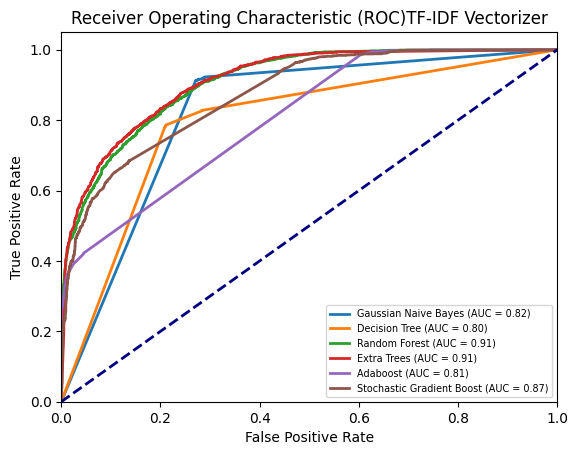

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models, 'TF-IDF Vectorizer')

##Word2Vec

In [ ]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id', 'post_created'], axis=1)
df_processed = df_processed.dropna()
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed

,post_id,post_text,label
0,655603836397076480,sostumblrx level hard,1
1,650490256370757633,think alexalltimelow show freak thank readi an...,1
2,811776053806891008,habit smell food even front peopl,0
3,566030675594051584,nanni ask would accept nanni offer less money ...,1
4,815056192925888512,harvest intern group,0
...,...,...,...
19790,599316758768517121,damnnnnn fifthharmoni worth video,1
19791,592843790416748544,sunshin avenu jess eisenberg luthor jeremi iro...,1
19792,618131606574772225,rickygervai imagin offend swear word tweet peo...,1
19793,521313370570772480,join congreg upperclass white peopl great idea...,1


In [ ]:
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
print(df_processed.isnull().sum())

post_id         0
post_text       0
is_depressed    0
dtype: int64


In [ ]:
# Training Word2Vec model
sentences = []
nltk.download('punkt')

for post in df_processed['post_text'].to_list():
  sentences.append(word_tokenize(post))

model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, workers=4, epochs=10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Accessing the vocabulary
vocabulary = model.wv.index_to_key

# Print the vocabulary
print("Vocabulary:", vocabulary)
print(len(vocabulary))

Vocabulary: ['like', 'depress', 'know', 'love', 'make', 'thank', 'want', 'peopl', 'think', 'good', 'user', 'time', 'follow', 'trump', 'need', 'year', 'feel', 'look', 'fuck', 'take', 'would', 'life', 'well', 'thing', 'much', 'treatment', 'help', 'work', 'misslusyd', 'twitter', 'never', 'still', 'right', 'come', 'realli', 'today', 'friend', 'happi', 'talk', 'even', 'yong', 'tell', 'back', 'realdonaldtrump', 'best', 'watch', 'start', 'stop', 'someon', 'tweet', 'pleas', 'person', 'shit', 'overcom', 'great', 'actual', 'ever', 'give', 'genevieveverso', 'find', 'could', 'first', 'hello', 'thefuxedo', 'wait', 'game', 'azarkansero', 'alway', 'girl', 'show', 'play', 'last', 'live', 'keep', 'someth', 'hope', 'morn', 'health', 'sleep', 'call', 'everyon', 'care', 'putin', 'also', 'migrain', 'real', 'mani', 'hate', 'video', 'mean', 'cameronhoodkin', 'chang', 'though', 'world', 'everi', 'mental', 'vote', 'famili', 'michael', 'posit', 'leav', 'kill', 'night', 'yeah', 'week', 'child', 'miss', 'hard', '

In [ ]:
def get_sentence_vector(sentences, model):
  word_vectors = []

  for word in sentences:
    if word in model.wv:
      word_vectors.append(model.wv[word])

  if len(word_vectors) == 0:
      return np.zeros(model.vector_size)

  sentence_vector = np.mean(word_vectors, axis=0)
  return sentence_vector

sentence_vector = []
for s in sentences:
  sentence_vector.append(get_sentence_vector(s, model))

In [ ]:
df_processed['post_text'] = sentence_vector
df_processed

,post_id,post_text,is_depressed
0,655603836397076480,"[-0.25107726, 0.45377398, 0.14956327, 0.001062...",1
1,650490256370757633,"[-0.40053034, 0.32266596, 0.25586465, -0.19139...",1
2,811776053806891008,"[-0.2608194, 0.40832075, 0.22774017, -0.006168...",0
3,566030675594051584,"[-0.30773363, 0.4895669, 0.17455858, 0.0814334...",1
4,815056192925888512,"[-0.27652285, 0.20467226, 0.13863716, -0.04007...",0
...,...,...,...
19790,599316758768517121,"[-0.46452075, 0.029499877, 0.27926052, -0.1020...",1
19791,592843790416748544,"[-0.20198947, 0.12046282, 0.0622458, -0.016592...",1
19792,618131606574772225,"[-0.2557821, 0.32289124, 0.12990573, -0.042116...",1
19793,521313370570772480,"[-0.3142584, 0.382271, 0.20273748, -0.03041293...",1


In [ ]:
X = np.array(sentence_vector)
y = np.array(df_processed['is_depressed'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  63.22303612023238 %
Precision: 67.19160104986877 %
Recall (Sensitivity): 51.717171717171716 %
Specificity: 74.73471450227387 %
F1-score: 58.4474885844749 %
              precision    recall  f1-score   support

           0       0.61      0.75      0.67      1979
           1       0.67      0.52      0.58      1980

    accuracy                           0.63      3959
   macro avg       0.64      0.63      0.63      3959
weighted avg       0.64      0.63      0.63      3959

True Positives: 1024
True Negatives: 1479
False Positives: 500
False Negatives: 956


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.6322594310972279


###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  66.10255114928012 %
Precision: 66.24236252545825 %
Recall (Sensitivity): 65.7070707070707 %
Specificity: 66.49823143001517 %
F1-score: 65.97363083164299 %
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1979
           1       0.66      0.66      0.66      1980

    accuracy                           0.66      3959
   macro avg       0.66      0.66      0.66      3959
weighted avg       0.66      0.66      0.66      3959

True Positives: 1301
True Negatives: 1316
False Positives: 663
False Negatives: 679


In [ ]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.6610265106854294


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  70.27027027027027 %
Precision: 69.76858690300345 %
Recall (Sensitivity): 71.56565656565657 %
Specificity: 68.97422940879233 %
F1-score: 70.65569683370731 %
              precision    recall  f1-score   support

           0       0.71      0.69      0.70      1979
           1       0.70      0.72      0.71      1980

    accuracy                           0.70      3959
   macro avg       0.70      0.70      0.70      3959
weighted avg       0.70      0.70      0.70      3959

True Positives: 1417
True Negatives: 1365
False Positives: 614
False Negatives: 563


In [ ]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.7026994298722444


###Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  70.62389492296035 %
Precision: 70.15293537247163 %
Recall (Sensitivity): 71.81818181818181 %
Specificity: 69.42900454775139 %
F1-score: 70.97579236336412 %
              precision    recall  f1-score   support

           0       0.71      0.69      0.70      1979
           1       0.70      0.72      0.71      1980

    accuracy                           0.71      3959
   macro avg       0.71      0.71      0.71      3959
weighted avg       0.71      0.71      0.71      3959

True Positives: 1422
True Negatives: 1374
False Positives: 605
False Negatives: 558


In [ ]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.706235931829666


###AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  66.6582470320788 %
Precision: 66.63306451612904 %
Recall (Sensitivity): 66.76767676767676 %
Specificity: 66.5487620010106 %
F1-score: 66.70030272452068 %
              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1979
           1       0.67      0.67      0.67      1980

    accuracy                           0.67      3959
   macro avg       0.67      0.67      0.67      3959
weighted avg       0.67      0.67      0.67      3959

True Positives: 1322
True Negatives: 1317
False Positives: 662
False Negatives: 658


In [ ]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.6665821938434369


###Stochastic Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, subsample=0.8, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.10836069714574 %
Precision: 68.5995085995086 %
Recall (Sensitivity): 70.5050505050505 %
Specificity: 67.71096513390602 %
F1-score: 69.53922789539227 %
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      1979
           1       0.69      0.71      0.70      1980

    accuracy                           0.69      3959
   macro avg       0.69      0.69      0.69      3959
weighted avg       0.69      0.69      0.69      3959

True Positives: 1396
True Negatives: 1340
False Positives: 639
False Negatives: 584


In [ ]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.6910800781947826


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


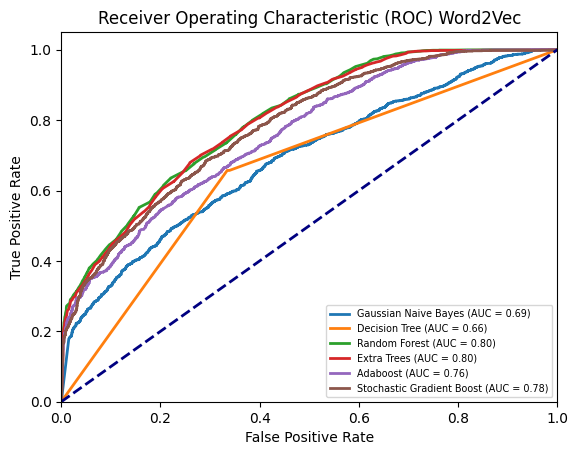

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models, ' Word2Vec')

##Neural Networks

In [ ]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.drop('post_created', axis=1)
df_processed

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,year sinc diagnos anxieti depress today take m...,1013187241,84,211,251,837,0,1
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,sewhq retro bear make perfect gift great begin...,1013187241,84,211,251,837,2,1
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
print(df_processed.isnull().sum())

post_id        0
post_text     86
user_id        0
followers      0
friends        0
favourites     0
statuses       0
retweets       0
label          0
dtype: int64


In [ ]:
df_processed = df_processed.dropna()
print(df_processed.isnull().sum())

post_id       0
post_text     0
user_id       0
followers     0
friends       0
favourites    0
statuses      0
retweets      0
label         0
dtype: int64


In [ ]:
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id'], axis=1)
df_processed

,post_id,post_text,label
0,637894677824413696,year sinc diagnos anxieti depress today take m...,1
1,637890384576778240,sunday need break plan spend littl time possibl,1
2,637749345908051968,awak tire need sleep brain idea,1
3,637696421077123073,sewhq retro bear make perfect gift great begin...,1
4,637696327485366272,hard whether pack list make life easi reinforc...,1
...,...,...,...
20233,819336825231773698,without sunshin like night,0
20234,819334654260080640,boren charg ponder troubl deleg doubt mumbl,0
20235,819334503042871297,flow chart thoroughli oversold piec program do...,0
20236,819334419374899200,ship safe harbor never mean stay,0


In [ ]:
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
print(df_processed.isnull().sum())

post_id         0
post_text       0
is_depressed    0
dtype: int64


In [ ]:
df_processed = df_processed.drop('post_id', axis=1)
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed

,post_text,is_depressed
0,nabilahudatahar hikaru mayb maksud despit diff...,0
1,stop shelley comment support tyler take social...,0
2,shirt life crap cotton short sleev adult shirt,1
3,aleph finish enemi walk,0
4,subtl protect client confidenti,1
...,...,...
19790,nocturnaltapir yoshimasa albino long nose tapeer,0
19791,fudd first opposit push someth hard enough fall,0
19792,impact daili routin,1
19793,epic chip ever pull chip,1


In [ ]:
#X = df_processed.drop('is_depressed', axis=1)
X = df_processed['post_text']
y = df_processed['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(len(max(df_processed['post_text'].to_list())))

42


In [ ]:
# Parameters
vocab_size = 5000  # Size of the vocabulary
embedding_dim = 50  # Size of the embedding vectors
max_sequence_length = len(max(df_processed['post_text'].to_list()))  # Maximum length of input sequences

# Tokenize the tweets
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df_processed['post_text'].to_list())
sequences = tokenizer.texts_to_sequences(df_processed['post_text'].to_list())

# Pad the sequences
X = pad_sequences(sequences, maxlen=vocab_size, padding='post')
y = np.array(df_processed['is_depressed'].to_list())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape, X_test.shape)

(15836, 5000) (3959, 5000)


In [ ]:
def reshape_input(X_train, y_train, X_test, y_test):
  # Ensure the data is in numpy array format
  X_train = np.array(X_train)
  y_train = np.array(y_train)
  X_test = np.array(X_test)
  y_test = np.array(y_test)


  print(f'Shape of X_train before reshaping: {X_train.shape}')
  print(f'Shape of X_test before reshaping: {X_test.shape}')

  # Reshape the input data to be 3-dimensional [samples, timesteps, features]
  X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
  X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


  # Print shapes after reshaping
  print(f'Shape of X_train after reshaping: {X_train.shape}')
  print(f'Shape of X_test after reshaping: {X_test.shape}')

  #X_train = X_train.vectorize()
  #X_test = X_test.vectorize()
  #y_train = y_train.vectorize()
  #y_test = y_test.vectorize()

  return X_train, y_train, X_test, y_test

####LSTM

In [ ]:
def LSTM_Neural_Net(X_train, y_train, X_test, y_test):
  X_train, y_train, X_test, y_test = reshape_input(X_train, y_train, X_test, y_test)

  #input_layer = Input(shape=(X_train.shape[1],))

  #embedding_layer = Embedding(input_dim=X_train.shape[1], output_dim=50, input_length=X_train.shape[1])(input_layer)

  #lstm_layer = Bidirectional(LSTM(16, activation='tanh', return_sequences=True))(embedding_layer)

  #query = Dense(64)(lstm_layer)
  #value = Dense(64)(lstm_layer)

  #attention_layer = Attention()([lstm_layer, lstm_layer])

  #global_max_pooling_layer = GlobalMaxPooling1D()(attention_layer)

  #dense_layer = Dense(8, activation='relu')(global_max_pooling_layer)

  #dropout_layer = Dropout(0.2)(dense_layer)

  #output_layer = Dense(1, activation='sigmoid')(dropout_layer)

  #model = Model(inputs=input_layer, outputs=output_layer)

  input_shape = (X_train.shape[1],)##############################################

  # Define the RNN model
  model = Sequential()
  model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=input_shape[0]))
  model.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[0], X_train.shape[1]))))
  #model.add(Attention())
  model.add(GlobalMaxPooling1D())
  #model.add(Dense(16, activation=LeakyReLU(alpha=0.01))) htan ektos kai prin
  model.add(Dense(64, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  model.build(input_shape=(None, input_shape[0]))########################################
  model.summary()

  plot_model(model, to_file='model_plot_lstm.png', show_shapes=True, show_layer_names=True)

  # Train the model
  model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2, shuffle=True)

  y_pred = model.predict(X_test)

  #print(y_pred)

  binary_predictions = []
  for curr_y in y_pred:
    if curr_y > 0.5:
      binary_predictions.append(1)
    else:
      binary_predictions.append(0)

  y_pred = binary_predictions

  test_loss, test_accuracy = model.evaluate(X_test, y_test)
  #print('Neural Network accuracy:', test_accuracy*100, "%")

  accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

  print(classification_report(y_test, y_pred))

  print_confusion_matrix(y_test, y_pred)

  auc = roc_auc_score(y_test, y_pred)
  print("ROC-AUC Score:", auc)

  return test_accuracy, model, auc

In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
with tf.device(device_name):
  lstm_accuracy, lstm_model, lstm_auc = LSTM_Neural_Net(X_train, y_train, X_test, y_test)

Shape of X_train before reshaping: (15836, 5000)
Shape of X_test before reshaping: (3959, 5000)
Shape of X_train after reshaping: (15836, 5000, 1)
Shape of X_test after reshaping: (3959, 5000, 1)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 5000, 100)           │         500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 5000, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 751,009 (2.86 MB)

 Trainable params: 751,009 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 145s 350ms/step - accuracy: 0.6351 - loss: 0.6110 - val_accuracy: 0.8299 - val_loss: 0.3415
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 206s 371ms/step - accuracy: 0.8841 - loss: 0.2590 - val_accuracy: 0.8441 - val_loss: 0.3249
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 200s 367ms/step - accuracy: 0.9118 - loss: 0.1964 - val_accuracy: 0.8415 - val_loss: 0.3695
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 194s 347ms/step - accuracy: 0.9317 - loss: 0.1492 - val_accuracy: 0.8393 - val_loss: 0.4325
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 150s 367ms/step - accuracy: 0.9377 - loss: 0.1341 - val_accuracy: 0.8374 - val_loss: 0.5085
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.8394 - loss: 0.5093
Accuracy:  83.88481939883809 %
Precision: 82.06800186306474 %
Recall (Sensitivity): 87.44416873449131 %
Specificity: 80.1954732510288 %
F1-score: 84.67083133109082 %
              precision    recall  f1-score   support

  

####CNN

In [ ]:
def CNN_Network(X_train, y_train, X_test, y_test):

  #X_train = np.array(X_train, dtype=np.float32)
  #X_test = np.array(X_test, dtype=np.float32)
  #y_train = np.array(y_train, dtype=np.float32)
  #y_test = np.array(y_test, dtype=np.float32)


  # Ensure input data is 3D and of type float32
  #X_train = np.expand_dims(X_train, axis=-1).astype(np.float32)  # Add a new axis at the end and convert to float32
  #X_test = np.expand_dims(X_test, axis=-1).astype(np.float32)    # Add a new axis at the end and convert to float32

  #X_train, y_train, X_test, y_test = reshape_input(X_train, y_train, X_test, y_test)

  input_shape = (X_train.shape[1],)##############################################

  # Define the RNN model
  model = Sequential()
  #model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=X_train.shape[1]))
  model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=input_shape[0]))
  model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))# ypirxe kai auto , input_shape=(X_train.shape[0], X_train.shape[1])
  #model.add(GlobalMaxPooling1D())
  model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))###############
  model.add(GlobalMaxPooling1D())###################
  model.add(Dense(64, activation=LeakyReLU(alpha=0.01)))
  #model.add(Dense(32, activation='relu'))
  #model.add(Dropout(0.2))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  model.build(input_shape=(None, input_shape[0]))########################################
  model.summary()

  plot_model(model, to_file='model_plot_cnn.png', show_shapes=True, show_layer_names=True)

  # Train the model
  model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

  y_pred = model.predict(X_test)

  #print(y_pred)

  binary_predictions = []
  for curr_y in y_pred:
    if curr_y > 0.5:
      binary_predictions.append(1)
    else:
      binary_predictions.append(0)

  y_pred = binary_predictions

  test_loss, test_accuracy = model.evaluate(X_test, y_test)
  #print('Neural Network accuracy:', test_accuracy*100, "%")

  accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

  print(classification_report(y_test, y_pred))

  print_confusion_matrix(y_test, y_pred)

  auc = roc_auc_score(y_test, y_pred)
  print("ROC-AUC Score:", auc)

  return test_accuracy, model, auc

In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
with tf.device(device_name):
  cnn_accuracy, cnn_model, cnn_auc = CNN_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 5000, 100)           │         500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 4996, 128)           │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 4992, 128)           │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 654,497 (2.50 MB)

 Trainable params: 654,497 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 44s 84ms/step - accuracy: 0.6401 - loss: 0.5822 - val_accuracy: 0.8362 - val_loss: 0.3396
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.8965 - loss: 0.2204 - val_accuracy: 0.8438 - val_loss: 0.3271
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9470 - loss: 0.1225 - val_accuracy: 0.8352 - val_loss: 0.4509
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9646 - loss: 0.0783 - val_accuracy: 0.8333 - val_loss: 0.6170
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9728 - loss: 0.0603 - val_accuracy: 0.8321 - val_loss: 0.7091
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8342 - loss: 0.7044
Accuracy:  83.6574892649659 %
Precision: 84.2 %
Recall (Sensitivity): 83.57320099255583 %
Specificity: 83.7448559670782 %
F1-score: 83.88542963885428 %
              precision    recall  f1-score   support

           0       0.83      0

#### LSTM-CNN Hybrid

In [ ]:
def Hybrid_Neural_Net(X_train, y_train, X_test, y_test):

  input_shape = (X_train.shape[1],)

  model = Sequential()
  model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=input_shape[0]))
  model.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[0], X_train.shape[1]))))
  model.add(GlobalMaxPooling1D())
  model.add(Dense(64, activation='relu'))
  model.add(Dropout(0.2))
  model.add(Reshape((64, 1)))
  model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
  model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
  model.add(GlobalMaxPooling1D())
  model.add(Dense(64, activation=LeakyReLU(alpha=0.01)))
  model.add(Dense(32, activation='relu'))#prin then ipirxe
  model.add(Dense(16, LeakyReLU(alpha=0.1)))#prin then ipirxe
  model.add(Dropout(0.5))#prin then ipirxe
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  model.build(input_shape=(None, input_shape[0]))
  model.summary()

  plot_model(model, to_file='hybrid_model_plot.png', show_shapes=True, show_layer_names=True)

  # Train the model
  model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

  y_pred = model.predict(X_test)


  binary_predictions = []
  for curr_y in y_pred:
    if curr_y > 0.5:
      binary_predictions.append(1)
    else:
      binary_predictions.append(0)

  y_pred = binary_predictions

  test_loss, test_accuracy = model.evaluate(X_test, y_test)

  accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

  print(classification_report(y_test, y_pred))

  print_confusion_matrix(y_test, y_pred)

  auc = roc_auc_score(y_test, y_pred)
  print("ROC-AUC Score:", auc)

  return test_accuracy, model, auc

In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

No GPU, using /device:CPU:0.


In [ ]:
with tf.device(device_name):
  hybrid_accuracy, hybrid_model, hybrid_auc = Hybrid_Neural_Net(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 5000, 100)           │         500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 5000, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_2               │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 64, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 60, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 56, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_3               │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 799,521 (3.05 MB)

 Trainable params: 799,521 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 152s 374ms/step - accuracy: 0.5756 - loss: 0.6481 - val_accuracy: 0.8217 - val_loss: 0.3774
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 146s 369ms/step - accuracy: 0.8588 - loss: 0.3276 - val_accuracy: 0.8419 - val_loss: 0.3390
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 203s 371ms/step - accuracy: 0.9130 - loss: 0.2192 - val_accuracy: 0.8277 - val_loss: 0.4007
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 193s 350ms/step - accuracy: 0.9283 - loss: 0.1642 - val_accuracy: 0.8355 - val_loss: 0.4165
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 146s 369ms/step - accuracy: 0.9452 - loss: 0.1368 - val_accuracy: 0.8488 - val_loss: 0.4909
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.8409 - loss: 0.4721
Accuracy:  83.7585248800202 %
Precision: 84.3687374749499 %
Recall (Sensitivity): 83.57320099255583 %
Specificity: 83.9506172839506 %
F1-score: 83.96908501620543 %
              precision    recall  f1-score   support

    

####Dense

In [ ]:
def Dense_Network(X_train, y_train, X_test, y_test):

  #X_train = np.array(X_train, dtype=np.float32)
  #X_test = np.array(X_test, dtype=np.float32)
  #y_train = np.array(y_train, dtype=np.float32)
  #y_test = np.array(y_test, dtype=np.float32)


  # Ensure input data is 3D and of type float32
  #X_train = np.expand_dims(X_train, axis=-1).astype(np.float32)  # Add a new axis at the end and convert to float32
  #X_test = np.expand_dims(X_test, axis=-1).astype(np.float32)    # Add a new axis at the end and convert to float32

  #X_train, y_train, X_test, y_test = reshape_input(X_train, y_train, X_test, y_test)

  # Define the RNN model
  model = Sequential()
  #model.add(Embedding(input_dim=X_train.shape[1], output_dim=100, input_length=X_train.shape[1]))
  model.add(Flatten(input_shape=X_train.shape[1:]))
  model.add(Dense(128, activation='relu', input_shape=(X_train.shape[0], X_train.shape[1])))
  #model.add(GlobalMaxPooling1D())
  model.add(Dense(64, activation=LeakyReLU(alpha=0.01)))
  model.add(Dense(32, activation='relu'))
  #model.add(Dropout(0.2))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  model.summary()

  plot_model(model, to_file='model_plot1.png', show_shapes=True, show_layer_names=True)

  # Train the model
  model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

  y_pred = model.predict(X_test)

  #print(y_pred)

  binary_predictions = []
  for curr_y in y_pred:
    if curr_y > 0.5:
      binary_predictions.append(1)
    else:
      binary_predictions.append(0)

  y_pred = binary_predictions

  test_loss, test_accuracy = model.evaluate(X_test, y_test)
  #print('Neural Network accuracy:', test_accuracy*100, "%")

  accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

  print(classification_report(y_test, y_pred))

  print_confusion_matrix(y_test, y_pred)

  auc = roc_auc_score(y_test, y_pred)
  print("ROC-AUC Score:", auc)

  return test_accuracy, model, auc

In [ ]:
with tf.device(device_name):
  dense_accuracy, dense_model, dense_auc = Dense_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 5000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         640,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 650,497 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4999 - loss: 2.6636 - val_accuracy: 0.5401 - val_loss: 0.9006
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5279 - loss: 0.7776 - val_accuracy: 0.5328 - val_loss: 0.7295
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5443 - loss: 0.7087 - val_accuracy: 0.5391 - val_loss: 0.7175
Epoch 4/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5365 - loss: 0.7014 - val_accuracy: 0.5202 - val_loss: 0.7102
Epoch 5/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5395 - loss: 0.7019 - val_accuracy: 0.5420 - val_loss: 0.7231
Epoch 6/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5354 - loss: 0.7017 - val_accuracy: 0.5420 - val_loss: 0.7023
Epoch 7/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5440 - loss: 0.6947 - val_accuracy: 0.5372 - val_loss: 0.6902
Epoch 8/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5442 - loss: 0.6898 - val_accuracy: 0.

126/126 [==============================] - 35s 281ms/step


TypeError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2381, in predict_step
        return self(x, training=False)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/lstm.py", line 616, in call
        timesteps = input_shape[0] if self.time_major else input_

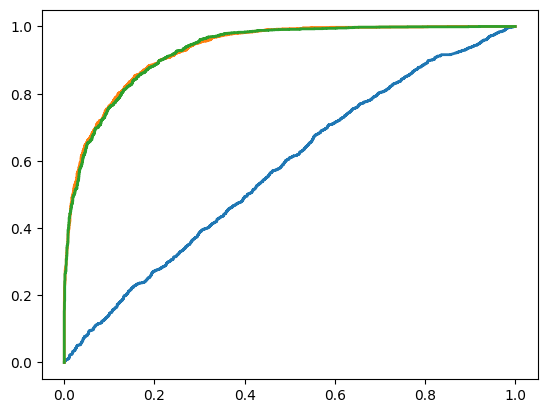

In [ ]:
models = {
    'Dense Neural Network': dense_model,
    'Convolutional Neural Network': cnn_model,
    'LSTM Neural Network': lstm_model,
    'Hybrid CNN-LSTM Neural Network': hybrid_model
}
draw_ROC_curves(X_test, y_test, models, ' ')

#Including Emojis

In [ ]:
df = pd.read_csv("Mental-Health-Twitter.csv").drop('Unnamed: 0', axis=1)
df

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
19995,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,A day without sunshine is like night.,1169875706,442,230,7,1063601,0,0
19996,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,"Boren's Laws: (1) When in charge, ponder. (2) ...",1169875706,442,230,7,1063601,0,0
19997,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,The flow chart is a most thoroughly oversold p...,1169875706,442,230,7,1063601,0,0
19998,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,"Ships are safe in harbor, but they were never ...",1169875706,442,230,7,1063601,0,0


In [ ]:
def extract_emojis(post_id_list, posts_list):

  emoji_dataframe = pd.DataFrame(columns=['post_id', 'emojis', 'emojis_count'])


  for id, post in zip(post_id_list, posts_list):

    ec = emoji.emoji_count(post)
    if ec == 0:
      emoji_list = []
    else:
      emoji_list = emoji.distinct_emoji_list(post)

    new_entry = pd.DataFrame({'post_id': [id], 'emojis': [emoji_list], 'emojis_count': [ec]})

    emoji_dataframe = pd.concat([emoji_dataframe, new_entry], ignore_index=True)

  return emoji_dataframe

In [ ]:
emoji_dataframe = extract_emojis(df['post_id'].to_list(), df['post_text'].to_list())
emoji_dataframe = emoji_dataframe.sample(frac=1).reset_index(drop=True)
emoji_dataframe

,post_id,emojis,emojis_count
0,817439169396035584,[],0
1,516909729940242432,[💁],1
2,677187410086744064,[],0
3,679700416276381696,[],0
4,3669907938,[],0
...,...,...,...
19995,810604187545378824,[],0
19996,3599466516,[],0
19997,819177237308178433,[],0
19998,3682644057,[],0


In [ ]:
print(emoji_dataframe['emojis_count'].value_counts())

emojis_count
0     18426
1      1000
2       293
3       147
4        50
5        22
6        21
7        14
9         7
8         5
14        4
12        2
19        1
10        1
25        1
30        1
11        1
22        1
20        1
15        1
58        1
Name: count, dtype: int64


In [ ]:
processed_posts = text_preprocessing(df['post_id'].to_list(), df['post_text'].to_list())
processed_posts

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


,post_id,post_text
0,637894677824413696,year sinc diagnos today take moment reflect co...
1,637890384576778240,sunday need break plan spend littl time possibl
2,637749345908051968,awak tire need sleep brain idea
3,637696421077123073,bear make perfect gift great beginn stitch oct...
4,637696327485366272,hard whether pack list make life easi reinforc...
...,...,...
19995,819336825231773698,without sunshin like night
19996,819334654260080640,boren charg ponder troubl deleg doubt mumbl
19997,819334503042871297,flow chart thoroughli oversold piec program do...
19998,819334419374899200,ship safe harbor never mean stay


In [ ]:
df_processed = df.drop("post_text", axis=1)
df_processed = pd.merge(df_processed, processed_posts, on='post_id', how='inner')
column = df_processed.pop('post_text')
df_processed.insert(df_processed.columns.get_loc('post_created') + 1, column.name, column)

df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos today take moment reflect co...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,bear make perfect gift great beginn stitch oct...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed.to_csv('Mental-Health-Twitter-Processed-With-Emojis.csv', index=False)

In [ ]:
df_processed = pd.read_csv('Mental-Health-Twitter-Processed-With-Emojis.csv').drop_duplicates(subset='post_id')
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,year sinc diagnos today take moment reflect co...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,bear make perfect gift great beginn stitch oct...,1013187241,84,211,251,837,2,1
4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,Thu Jan 12 00:14:56 +0000 2017,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,Thu Jan 12 00:06:18 +0000 2017,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,Thu Jan 12 00:05:42 +0000 2017,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,Thu Jan 12 00:05:22 +0000 2017,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.drop('post_created', axis=1)
df_processed = df_processed.dropna()
df_processed

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,year sinc diagnos today take moment reflect co...,1013187241,84,211,251,837,0,1
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1
3,637696421077123073,bear make perfect gift great beginn stitch oct...,1013187241,84,211,251,837,2,1
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1
...,...,...,...,...,...,...,...,...,...
20233,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0
20234,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0
20235,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0
20236,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0


In [ ]:
df_processed = df_processed.rename(columns={'label': 'is_depressed'})
print(df_processed.isnull().sum())

post_id         0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
is_depressed    0
dtype: int64


In [ ]:
print(df_processed['is_depressed'].value_counts())

is_depressed
0    9813
1    9715
Name: count, dtype: int64


In [ ]:
df_processed_with_emojis = pd.merge(df_processed, emoji_dataframe, how='inner', on='post_id')
df_processed_with_emojis

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed,emojis,emojis_count
0,637894677824413696,year sinc diagnos today take moment reflect co...,1013187241,84,211,251,837,0,1,[],0
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1,[],0
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1,[],0
3,637696421077123073,bear make perfect gift great beginn stitch oct...,1013187241,84,211,251,837,2,1,[],0
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1,[],0
...,...,...,...,...,...,...,...,...,...,...,...
19641,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0,[],0
19642,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0,[],0
19643,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0,[],0
19644,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0,[],0


In [ ]:
def emoji_sentiment_extraction(post_id_list, emojis_list):

  emoji_sentiment_df = pd.DataFrame(columns=['post_id', 'emoji', 'sentiment_score'])

  for id, emoji_list in zip(post_id_list, emojis_list):

    for emoji in emoji_list:

      if len(emoji_list) == 0:
        new_entry = pd.DataFrame({'post_id': [id], 'emoji': [emoji], 'sentiment_score': [0]})
        emoji_sentiment_df = pd.concat([emoji_sentiment_df, new_entry], ignore_index=True)
      else:
        emoji_data = get_emoji_sentiment_rank(emoji)
        if emoji_data is not None:
          sentiment_score = emoji_data['sentiment_score']
        else:
          sentiment_score = 0

        new_entry = pd.DataFrame({'post_id': [id], 'emoji': [emoji], 'sentiment_score': [sentiment_score]})
        emoji_sentiment_df = pd.concat([emoji_sentiment_df, new_entry], ignore_index=True)

  return emoji_sentiment_df

In [ ]:
emoji_sentiment_df = emoji_sentiment_extraction(df_processed_with_emojis['post_id'].to_list(), df_processed_with_emojis['emojis'].to_list())
emoji_sentiment_df = emoji_sentiment_df.sample(frac=1).reset_index(drop=True)
emoji_sentiment_df

,post_id,emoji,sentiment_score
0,811331247112912896,💋,0.693
1,818054689531056129,🎈,0.726
2,813097537154482178,🎄,0.538
3,814953448558858240,🎂,0.622
4,663954241799622656,💙,0.732
...,...,...,...
2056,563657706926784512,❤️,0
2057,817009580874010624,🇷🇺,0
2058,809582884919115776,😂,0.221
2059,600417696740704257,😏,0.332


In [ ]:
print(emoji_sentiment_df['sentiment_score'].value_counts())

sentiment_score
 0.000    439
 0.221    228
-0.093     79
 0.678     64
 0.645     63
         ... 
-0.136      1
 0.322      1
 0.030      1
 0.811      1
 0.624      1
Name: count, Length: 205, dtype: int64


In [ ]:
print(len(emoji_sentiment_df['post_id'].value_counts()))

1532


In [ ]:
emoji_sentiment_df = pd.merge(df_processed_with_emojis, emoji_sentiment_df, how='left', on='post_id')
emoji_sentiment_df

,post_id,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed,emojis,emojis_count,emoji,sentiment_score
0,637894677824413696,year sinc diagnos today take moment reflect co...,1013187241,84,211,251,837,0,1,[],0,NaN,NaN
1,637890384576778240,sunday need break plan spend littl time possibl,1013187241,84,211,251,837,1,1,[],0,NaN,NaN
2,637749345908051968,awak tire need sleep brain idea,1013187241,84,211,251,837,0,1,[],0,NaN,NaN
3,637696421077123073,bear make perfect gift great beginn stitch oct...,1013187241,84,211,251,837,2,1,[],0,NaN,NaN
4,637696327485366272,hard whether pack list make life easi reinforc...,1013187241,84,211,251,837,1,1,[],0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,819336825231773698,without sunshin like night,1169875706,442,230,7,1063601,0,0,[],0,NaN,NaN
20182,819334654260080640,boren charg ponder troubl deleg doubt mumbl,1169875706,442,230,7,1063601,0,0,[],0,NaN,NaN
20183,819334503042871297,flow chart thoroughli oversold piec program do...,1169875706,442,230,7,1063601,0,0,[],0,NaN,NaN
20184,819334419374899200,ship safe harbor never mean stay,1169875706,442,230,7,1063601,0,0,[],0,NaN,NaN


In [ ]:
emoji_sentiment_df = emoji_sentiment_df.drop(['emoji', 'emojis', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'emojis_count'],axis=1)
emoji_sentiment_df

,post_id,post_text,is_depressed,sentiment_score
0,637894677824413696,year sinc diagnos today take moment reflect co...,1,NaN
1,637890384576778240,sunday need break plan spend littl time possibl,1,NaN
2,637749345908051968,awak tire need sleep brain idea,1,NaN
3,637696421077123073,bear make perfect gift great beginn stitch oct...,1,NaN
4,637696327485366272,hard whether pack list make life easi reinforc...,1,NaN
...,...,...,...,...
20181,819336825231773698,without sunshin like night,0,NaN
20182,819334654260080640,boren charg ponder troubl deleg doubt mumbl,0,NaN
20183,819334503042871297,flow chart thoroughli oversold piec program do...,0,NaN
20184,819334419374899200,ship safe harbor never mean stay,0,NaN


In [ ]:
print(emoji_sentiment_df.isnull().sum())

post_id                0
post_text              0
is_depressed           0
sentiment_score    18105
dtype: int64


In [ ]:
emoji_sentiment_df = emoji_sentiment_df.fillna(0)
print(emoji_sentiment_df.isnull().sum())

post_id            0
post_text          0
is_depressed       0
sentiment_score    0
dtype: int64


##TF-IDF Vectorizer

In [ ]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer to the data and transform the tweets into a TF-IDF representation
tfidf_matrix = tfidf_vectorizer.fit_transform(emoji_sentiment_df['post_text'].to_list())

# Get the list of feature names (words)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Print the TF-IDF matrix
print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

TF-IDF Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# Print the feature names
print("\nFeature Names:")
print(tfidf_feature_names)


Feature Names:
['aaron' 'abandon' 'abbi' ... 'zquad' 'zurab' 'zwart']


In [ ]:
emoji_sentiment_df['post_text'] = list(tfidf_matrix.toarray())
emoji_sentiment_df

,post_id,post_text,is_depressed,sentiment_score
0,637894677824413696,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0
1,637890384576778240,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0
2,637749345908051968,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0
3,637696421077123073,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0
4,637696327485366272,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0
...,...,...,...,...
20181,819336825231773698,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0
20182,819334654260080640,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0
20183,819334503042871297,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0
20184,819334419374899200,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0


In [ ]:
df_post_text_final = pd.DataFrame(emoji_sentiment_df['post_text'].to_list(), columns=tfidf_feature_names)
df_post_text_final['post_id'] = emoji_sentiment_df['post_id']
df_post_text_final

,aaron,abandon,abbi,abil,abl,abort,abroad,absenc,absolut,abus,...,zenhabit,zero,zimmermann,zink,znati,zone,zquad,zurab,zwart,post_id
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637894677824413696
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637890384576778240
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637749345908051968
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637696421077123073
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637696327485366272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,819336825231773698
20182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,819334654260080640
20183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,819334503042871297
20184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,819334419374899200


In [ ]:
#NEW CODE
emoji_sentiment_df = emoji_sentiment_df.sort_values(by='post_id', ascending=False).reset_index()
emoji_sentiment_df = emoji_sentiment_df.drop('index', axis=1)

df_post_text_final = df_post_text_final.sort_values(by='post_id', ascending=False).reset_index()
df_post_text_final = df_post_text_final.drop('index', axis=1)

df_post_text_final['is_depressed'] = emoji_sentiment_df['is_depressed']
emoji_sentiment_df = df_post_text_final.drop('post_id', axis=1)
emoji_sentiment_df = emoji_sentiment_df.drop('level_0', axis=1)
emoji_sentiment_df

,aaron,abandon,abbi,abil,abl,abort,abroad,absenc,absolut,abus,...,zenhabit,zero,zimmermann,zink,znati,zone,zquad,zurab,zwart,is_depressed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
emoji_sentiment_df.to_csv('Final-Tweets-Processed-TFIDFVectorized-With-Emojis.csv', index=False)

In [ ]:
emoji_sentiment_df = pd.read_csv('Final-Tweets-Processed-TFIDFVectorized-With-Emojis.csv')
emoji_sentiment_df

,aaron,abandon,abbi,abil,abl,abort,abroad,absenc,absolut,abus,...,zenhabit,zero,zimmermann,zink,znati,zone,zquad,zurab,zwart,is_depressed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
20184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
X = emoji_sentiment_df.drop('is_depressed', axis=1)
y = emoji_sentiment_df['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.73749380881624 %
Precision: 63.732394366197184 %
Recall (Sensitivity): 90.40959040959041 %
Specificity: 49.41060903732809 %
F1-score: 74.76249483684428 %
              precision    recall  f1-score   support

           0       0.84      0.49      0.62      2036
           1       0.64      0.90      0.75      2002

    accuracy                           0.70      4038
   macro avg       0.74      0.70      0.68      4038
weighted avg       0.74      0.70      0.68      4038

True Positives: 1810
True Negatives: 1006
False Positives: 1030
False Negatives: 192


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.6991009972345925


###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  71.09955423476968 %
Precision: 70.88544272136068 %
Recall (Sensitivity): 70.77922077922078 %
Specificity: 71.41453831041258 %
F1-score: 70.83229192701823 %
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      2036
           1       0.71      0.71      0.71      2002

    accuracy                           0.71      4038
   macro avg       0.71      0.71      0.71      4038
weighted avg       0.71      0.71      0.71      4038

True Positives: 1417
True Negatives: 1454
False Positives: 582
False Negatives: 585


In [ ]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.7109687954481668


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  73.0064388311045 %
Precision: 72.44094488188976 %
Recall (Sensitivity): 73.52647352647352 %
Specificity: 72.4950884086444 %
F1-score: 72.97967278135845 %
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      2036
           1       0.72      0.74      0.73      2002

    accuracy                           0.73      4038
   macro avg       0.73      0.73      0.73      4038
weighted avg       0.73      0.73      0.73      4038

True Positives: 1472
True Negatives: 1476
False Positives: 560
False Negatives: 530


In [ ]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.7301078096755897


###Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  74.17038137691927 %
Precision: 72.04597701149426 %
Recall (Sensitivity): 78.27172827172826 %
Specificity: 70.13752455795678 %
F1-score: 75.02992578405554 %
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      2036
           1       0.72      0.78      0.75      2002

    accuracy                           0.74      4038
   macro avg       0.74      0.74      0.74      4038
weighted avg       0.74      0.74      0.74      4038

True Positives: 1567
True Negatives: 1428
False Positives: 608
False Negatives: 435


In [ ]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.7420462641484252


###Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  64.5864289252105 %
Precision: 78.54291417165669 %
Recall (Sensitivity): 39.31068931068931 %
Specificity: 89.44007858546169 %
F1-score: 52.39680426098536 %
              precision    recall  f1-score   support

           0       0.60      0.89      0.72      2036
           1       0.79      0.39      0.52      2002

    accuracy                           0.65      4038
   macro avg       0.69      0.64      0.62      4038
weighted avg       0.69      0.65      0.62      4038

True Positives: 787
True Negatives: 1821
False Positives: 215
False Negatives: 1215


In [ ]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.643753839480755


###Stochastic Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.46508172362556 %
Precision: 73.43083485679463 %
Recall (Sensitivity): 60.18981018981019 %
Specificity: 78.58546168958742 %
F1-score: 66.1542684600604 %
              precision    recall  f1-score   support

           0       0.67      0.79      0.72      2036
           1       0.73      0.60      0.66      2002

    accuracy                           0.69      4038
   macro avg       0.70      0.69      0.69      4038
weighted avg       0.70      0.69      0.69      4038

True Positives: 1205
True Negatives: 1600
False Positives: 436
False Negatives: 797


In [ ]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.693876359396988


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


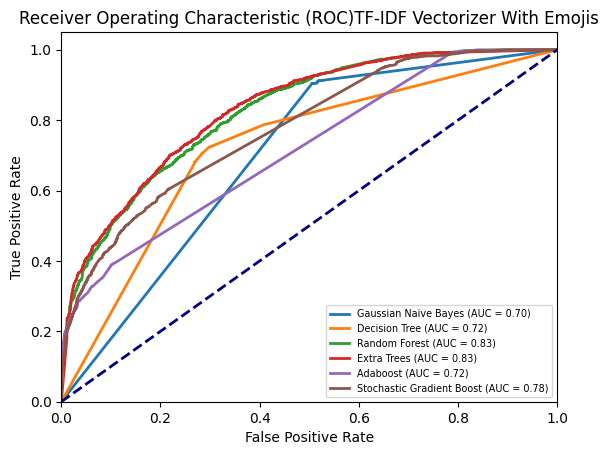

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models, 'TF-IDF Vectorizer With Emojis')

##Neural Networks

In [ ]:
# Parameters
vocab_size = 5000  # Size of the vocabulary
embedding_dim = 50  # Size of the embedding vectors
max_sequence_length = len(max(emoji_sentiment_df['post_text'].to_list()))  # Maximum length of input sequences

# Tokenize the tweets
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(emoji_sentiment_df['post_text'].to_list())
sequences = tokenizer.texts_to_sequences(emoji_sentiment_df['post_text'].to_list())

# Pad the sequences
X = pad_sequences(sequences, maxlen=vocab_size, padding='post')
y = np.array(emoji_sentiment_df['is_depressed'].to_list())

X = np.concatenate((X, np.array(emoji_sentiment_df['sentiment_score']).reshape(-1, 1)), axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape)

(20186, 5001)


In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
with tf.device(device_name):
  dense_accuracy, dense_model, dense_auc = Dense_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 5001)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │         640,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 650,625 (2.48 MB)

 Trainable params: 650,625 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5123 - loss: 1.6088 - val_accuracy: 0.5254 - val_loss: 0.7638
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5223 - loss: 0.7117 - val_accuracy: 0.5279 - val_loss: 0.6813
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5515 - loss: 0.6795 - val_accuracy: 0.5514 - val_loss: 0.6772
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5499 - loss: 0.6746 - val_accuracy: 0.5461 - val_loss: 0.6776
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5578 - loss: 0.6747 - val_accuracy: 0.5282 - val_loss: 0.6795
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5513 - loss: 0.6750 - val_accuracy: 0.5263 - val_loss: 0.6777
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5464 - loss: 0.6762 - val_accuracy: 0.5356 - val_loss: 0.6765
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5448 - loss: 0.6760 - val_accuracy: 0.

In [ ]:
with tf.device(device_name):
  lstm_accuracy, lstm_model, lstm_auc = LSTM_Neural_Net(X_train, y_train, X_test, y_test)

Shape of X_train before reshaping: (16148, 5001)
Shape of X_test before reshaping: (4038, 5001)
Shape of X_train after reshaping: (16148, 5001, 1)
Shape of X_test after reshaping: (4038, 5001, 1)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 5001, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_4               │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 751,109 (2.87 MB)

 Trainable params: 751,109 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 144s 351ms/step - accuracy: 0.5875 - loss: 0.6515 - val_accuracy: 0.7536 - val_loss: 0.4962
Epoch 2/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 201s 348ms/step - accuracy: 0.8018 - loss: 0.4224 - val_accuracy: 0.7638 - val_loss: 0.4782
Epoch 3/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 150s 368ms/step - accuracy: 0.8488 - loss: 0.3274 - val_accuracy: 0.7601 - val_loss: 0.4988
Epoch 4/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 194s 348ms/step - accuracy: 0.8714 - loss: 0.2819 - val_accuracy: 0.7533 - val_loss: 0.5797
Epoch 5/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 349ms/step - accuracy: 0.8849 - loss: 0.2509 - val_accuracy: 0.7598 - val_loss: 0.6732
127/127 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.7298 - loss: 0.7587
Accuracy:  73.27885091629518 %
Precision: 71.30242825607064 %
Recall (Sensitivity): 79.01174168297456 %
Specificity: 67.40220661985958 %
F1-score: 74.95938732884659 %
              precision    recall  f1-score   support

 

In [ ]:
with tf.device(device_name):
  cnn_accuracy, cnn_model, cnn_auc = CNN_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 4997, 128)           │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 4993, 128)           │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_5               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 654,597 (2.50 MB)

 Trainable params: 654,597 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.5880 - loss: 0.6396 - val_accuracy: 0.7368 - val_loss: 0.4937
Epoch 2/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.8006 - loss: 0.4079 - val_accuracy: 0.7529 - val_loss: 0.5103
Epoch 3/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.8723 - loss: 0.2753 - val_accuracy: 0.7539 - val_loss: 0.5977
Epoch 4/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.9241 - loss: 0.1726 - val_accuracy: 0.7514 - val_loss: 0.7526
Epoch 5/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 30s 73ms/step - accuracy: 0.9413 - loss: 0.1305 - val_accuracy: 0.7409 - val_loss: 1.0785
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7193 - loss: 1.2643
Accuracy:  71.19861317483902 %
Precision: 72.44014263881814 %
Recall (Sensitivity): 69.56947162426614 %
Specificity: 72.86860581745236 %
F1-score: 70.97579236336414 %
              precision    recall  f1-score   support

           0   

In [ ]:
with tf.device(device_name):
  hybrid_accuracy, hybrid_model, hybrid_auc = Hybrid_Neural_Net(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 5001, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_6               │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 64, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 60, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 56, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_7               │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 799,621 (3.05 MB)

 Trainable params: 799,621 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 146s 353ms/step - accuracy: 0.4991 - loss: 0.6932 - val_accuracy: 0.4895 - val_loss: 0.6934
Epoch 2/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 201s 350ms/step - accuracy: 0.5045 - loss: 0.6932 - val_accuracy: 0.4895 - val_loss: 0.6933
Epoch 3/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 349ms/step - accuracy: 0.4973 - loss: 0.6932 - val_accuracy: 0.4895 - val_loss: 0.6933
Epoch 4/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 140s 343ms/step - accuracy: 0.4927 - loss: 0.6932 - val_accuracy: 0.4895 - val_loss: 0.6934
Epoch 5/5
404/404 ━━━━━━━━━━━━━━━━━━━━ 157s 381ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.4895 - val_loss: 0.6933
127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.5089 - loss: 0.6931
Accuracy:  50.61911837543338 %
Precision: 50.61911837543338 %
Recall (Sensitivity): 100.0 %
Specificity: 0.0 %
F1-score: 67.21473199605393 %
              precision    recall  f1-score   support

           0       0.00    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#Sentiment Analysis

In [46]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed = df_processed.dropna()
#df_processed = df_processed.drop_duplicates()
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed.rename(columns={'label': 'is_depressed'}, inplace=True)
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed
0,626820785903112197,Thu Jul 30 18:24:55 +0000 2015,ayykaitlyn respons feel empow know,49548465,677,1644,8375,12913,1,1
1,709853300703670272,Tue Mar 15 21:26:29 +0000 2016,famili jose cruz pictur duti farmer branch off...,325328455,3185,1447,1250,5186,40,1
2,593644613287677952,Thu Apr 30 05:14:39 +0000 2015,cancer kill life voxxi depress treatment,1616997456,476,1235,0,21533,0,1
3,3643459365,Sun Aug 30 11:03:28 +0000 2009,could daili exercis help prevent migrain,60868031,1768,532,3,5720,0,1
4,818934399689457664,Tue Jan 10 21:35:50 +0000 2017,tedcruz wonder realdonaldtrump keep refer lyin...,18831261,884,2389,8466,57269,0,0
...,...,...,...,...,...,...,...,...,...,...
19790,677410757139566593,Thu Dec 17 08:51:24 +0000 2015,sleep attempt number lessdothi,20118423,288,988,280,6694,1,1
19791,817390163475120128,Fri Jan 06 15:19:36 +0000 2017,comicbooknow celen dion make pokemon heartbrea...,490044008,1849,561,8229,86352,37,0
19792,3676315073,Mon Aug 31 23:31:39 +0000 2009,migrain pleas help beg,60868031,1768,532,3,5720,0,1
19793,573172022932447232,Wed Mar 04 17:23:53 +0000 2015,class liter listen play song school radio noth...,3015971504,914,489,8717,3359,0,1


In [47]:
print(df_processed.isnull().sum())
print(df_processed['is_depressed'].value_counts())

post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
is_depressed    0
dtype: int64
is_depressed
0    9904
1    9891
Name: count, dtype: int64


In [48]:
def sentiment_analysis(post_id_list, posts_list):

  nltk.download('vader_lexicon')

  sia = SentimentIntensityAnalyzer()

  df_sentiment = pd.DataFrame(columns=['post_id', 'sentiment_score'])

  for post_id, post in zip(post_id_list, posts_list):

    sentiment_scores = sia.polarity_scores(post)
    score = sentiment_scores['compound']

    new_entry = pd.DataFrame({'post_id': [post_id], 'sentiment_score': [score]})

    df_sentiment = pd.concat([df_sentiment, new_entry], ignore_index=True)

  return df_sentiment

In [49]:
df_sentiment = sentiment_analysis(df_processed['post_id'].to_list(), df_processed['post_text'].to_list())
df_sentiment

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
<ipython-input-48-457908560768>:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sentiment = pd.concat([df_sentiment, new_entry], ignore_index=True)


,post_id,sentiment_score
0,626820785903112197,0.0000
1,709853300703670272,-0.3400
2,593644613287677952,-0.9231
3,3643459365,0.4215
4,818934399689457664,0.0000
...,...,...
19790,677410757139566593,0.0772
19791,817390163475120128,-0.5719
19792,3676315073,0.4019
19793,573172022932447232,0.5106


In [50]:
print(df_sentiment.isnull().sum())

post_id            0
sentiment_score    0
dtype: int64


In [51]:
df_processed = pd.merge(df_processed, df_sentiment, on='post_id', how='inner')
#df_processed = df_processed.drop_duplicates()
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed,sentiment_score
0,626820785903112197,Thu Jul 30 18:24:55 +0000 2015,ayykaitlyn respons feel empow know,49548465,677,1644,8375,12913,1,1,0.0000
1,709853300703670272,Tue Mar 15 21:26:29 +0000 2016,famili jose cruz pictur duti farmer branch off...,325328455,3185,1447,1250,5186,40,1,-0.3400
2,593644613287677952,Thu Apr 30 05:14:39 +0000 2015,cancer kill life voxxi depress treatment,1616997456,476,1235,0,21533,0,1,-0.9231
3,3643459365,Sun Aug 30 11:03:28 +0000 2009,could daili exercis help prevent migrain,60868031,1768,532,3,5720,0,1,0.4215
4,818934399689457664,Tue Jan 10 21:35:50 +0000 2017,tedcruz wonder realdonaldtrump keep refer lyin...,18831261,884,2389,8466,57269,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
19790,677410757139566593,Thu Dec 17 08:51:24 +0000 2015,sleep attempt number lessdothi,20118423,288,988,280,6694,1,1,0.0772
19791,817390163475120128,Fri Jan 06 15:19:36 +0000 2017,comicbooknow celen dion make pokemon heartbrea...,490044008,1849,561,8229,86352,37,0,-0.5719
19792,3676315073,Mon Aug 31 23:31:39 +0000 2009,migrain pleas help beg,60868031,1768,532,3,5720,0,1,0.4019
19793,573172022932447232,Wed Mar 04 17:23:53 +0000 2015,class liter listen play song school radio noth...,3015971504,914,489,8717,3359,0,1,0.5106


##CountVectorizer

In [ ]:
# Initialize CountVectorizer
vectorizer = CountVectorizer(max_features=5000)

# Fit the vectorizer to the data and transform the tweets into a bag of words representation
bow_matrix = vectorizer.fit_transform(df_processed['post_text'].to_list())

# Get the list of feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Print the bag of words matrix
print("Bag of Words Matrix:")
print(bow_matrix.toarray())

Bag of Words Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
df_processed['post_text'] = list(bow_matrix.toarray())
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id'], axis=1)
df_processed

,post_id,post_created,post_text,is_depressed,sentiment_score
0,810808402074963968,Mon Dec 19 11:26:01 +0000 2016,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0.0000
1,528820984951083008,Sun Nov 02 08:08:42 +0000 2014,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,0.7184
2,589996452627218433,Mon Apr 20 03:38:10 +0000 2015,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,0.6908
3,819438873700954112,Thu Jan 12 07:00:26 +0000 2017,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0.0000
4,529492120185610240,Tue Nov 04 04:35:33 +0000 2014,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,0.2263
...,...,...,...,...,...
19790,648078783333859329,Sun Sep 27 10:16:37 +0000 2015,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,0.7184
19791,818104490515693568,Sun Jan 08 14:38:04 +0000 2017,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0.0000
19792,576993530435936256,Sun Mar 15 06:29:12 +0000 2015,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,-0.1027
19793,660414761209843712,Sat Oct 31 11:15:23 +0000 2015,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,-0.5423


In [ ]:
print(df_processed.isnull().sum())
print(df_processed['post_id'].nunique())

post_id            0
post_created       0
post_text          0
is_depressed       0
sentiment_score    0
dtype: int64
19795


In [ ]:
df_post_text_final = pd.DataFrame(df_processed['post_text'].to_list(), columns=feature_names)

df_post_text_final['post_id'] = df_processed['post_id']
df_post_text_final['sentiment_score'] = df_processed['sentiment_score']
df_post_text_final

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,post_id,sentiment_score
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,810808402074963968,0.0000
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,528820984951083008,0.7184
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,589996452627218433,0.6908
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,819438873700954112,0.0000
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,529492120185610240,0.2263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,648078783333859329,0.7184
19791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,818104490515693568,0.0000
19792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,576993530435936256,-0.1027
19793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,660414761209843712,-0.5423


In [ ]:
print(df_post_text_final.isnull().sum())
print(df_post_text_final['post_id'].nunique())

aaron              0
aaroncarpent       0
aartoria           0
abandon            0
abbi               0
                  ..
zone               0
zquad              0
zurab              0
post_id            0
sentiment_score    0
Length: 5002, dtype: int64
19795


In [ ]:
#NEW CODE
df_processed = df_processed.sort_values(by='post_id', ascending=False).reset_index()
df_processed = df_processed.drop('index', axis=1)

df_post_text_final = df_post_text_final.sort_values(by='post_id', ascending=False).reset_index()
df_post_text_final = df_post_text_final.drop('index', axis=1)
#df_post_text_final = df_post_text_final.dropna()

df_post_text_final['is_depressed'] = df_processed['is_depressed']
df_processed = df_post_text_final.drop('post_id', axis=1)
df_processed = df_processed.drop('level_0', axis=1)
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,sentiment_score,is_depressed
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0516,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0000,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,-0.3818,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0772,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.7650,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0000,1
19791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.4019,1
19792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0000,1
19793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0000,1


In [ ]:
print(df_processed.isnull().sum())
print(df_processed['is_depressed'].value_counts())

aaron              0
aaroncarpent       0
aartoria           0
abandon            0
abbi               0
                  ..
zone               0
zquad              0
zurab              0
sentiment_score    0
is_depressed       0
Length: 5001, dtype: int64
is_depressed
0    9904
1    9891
Name: count, dtype: int64


In [ ]:
X = df_processed.drop('is_depressed', axis=1)
y = df_processed['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  83.20282899722152 %
Precision: 77.49371332774518 %
Recall (Sensitivity): 93.52554375316136 %
Specificity: 72.90615539858727 %
F1-score: 84.75819390327756 %
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1982
           1       0.77      0.94      0.85      1977

    accuracy                           0.83      3959
   macro avg       0.85      0.83      0.83      3959
weighted avg       0.85      0.83      0.83      3959

True Positives: 1849
True Negatives: 1445
False Positives: 537
False Negatives: 128


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.8321584957587432


###Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.20156605203334 %
Precision: 78.01810865191146 %
Recall (Sensitivity): 78.45220030349014 %
Specificity: 77.95156407669022 %
F1-score: 78.23455233291298 %
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1982
           1       0.78      0.78      0.78      1977

    accuracy                           0.78      3959
   macro avg       0.78      0.78      0.78      3959
weighted avg       0.78      0.78      0.78      3959

True Positives: 1551
True Negatives: 1545
False Positives: 437
False Negatives: 426


In [ ]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.7820188219009018


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  81.58625915635261 %
Precision: 79.62962962962963 %
Recall (Sensitivity): 84.82549317147192 %
Specificity: 78.35519677093845 %
F1-score: 82.14548126377663 %
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1982
           1       0.80      0.85      0.82      1977

    accuracy                           0.82      3959
   macro avg       0.82      0.82      0.82      3959
weighted avg       0.82      0.82      0.82      3959

True Positives: 1677
True Negatives: 1553
False Positives: 429
False Negatives: 300


In [ ]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.8159034497120519


###Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  82.29350846173276 %
Precision: 81.1219512195122 %
Recall (Sensitivity): 84.11734951947395 %
Specificity: 80.47426841574168 %
F1-score: 82.59250062080953 %
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1982
           1       0.81      0.84      0.83      1977

    accuracy                           0.82      3959
   macro avg       0.82      0.82      0.82      3959
weighted avg       0.82      0.82      0.82      3959

True Positives: 1663
True Negatives: 1595
False Positives: 387
False Negatives: 314


In [ ]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.8229580896760781


###Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.96716342510734 %
Precision: 62.676962676962674 %
Recall (Sensitivity): 98.53313100657563 %
Specificity: 41.47325933400605 %
F1-score: 76.61750245821042 %
              precision    recall  f1-score   support

           0       0.97      0.41      0.58      1982
           1       0.63      0.99      0.77      1977

    accuracy                           0.70      3959
   macro avg       0.80      0.70      0.67      3959
weighted avg       0.80      0.70      0.67      3959

True Positives: 1948
True Negatives: 822
False Positives: 1160
False Negatives: 29


In [ ]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.7000319517029083


###Stochastic Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, subsample=0.8, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [ ]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  77.67112907299824 %
Precision: 81.90309398715704 %
Recall (Sensitivity): 70.96611026808294 %
Specificity: 84.35923309788093 %
F1-score: 76.04336043360433 %
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      1982
           1       0.82      0.71      0.76      1977

    accuracy                           0.78      3959
   macro avg       0.78      0.78      0.78      3959
weighted avg       0.78      0.78      0.78      3959

True Positives: 1403
True Negatives: 1672
False Positives: 310
False Negatives: 574


In [ ]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.7766267168298193


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


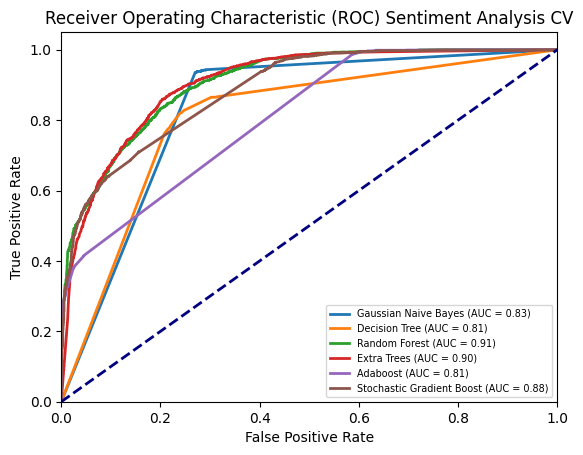

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models, ' Sentiment Analysis CV')

##Neural Networks

In [ ]:
# Parameters
vocab_size = 5000  # Size of the vocabulary
embedding_dim = 50  # Size of the embedding vectors
max_sequence_length = len(max(df_processed['post_text'].to_list()))  # Maximum length of input sequences

# Tokenize the tweets
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df_processed['post_text'].to_list())
sequences = tokenizer.texts_to_sequences(df_processed['post_text'].to_list())

# Pad the sequences
X = pad_sequences(sequences, maxlen=vocab_size, padding='post')
y = np.array(df_processed['is_depressed'].to_list())

X = np.concatenate((X, np.array(df_processed['sentiment_score']).reshape(-1, 1)), axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

Found GPU at: /device:GPU:0


####LSTM

In [ ]:
with tf.device(device_name):
  lstm_accuracy, lstm_model, lstm_auc = LSTM_Neural_Net(X_train, y_train, X_test, y_test)

Shape of X_train before reshaping: (15836, 5001)
Shape of X_test before reshaping: (3959, 5001)
Shape of X_train after reshaping: (15836, 5001, 1)
Shape of X_test after reshaping: (3959, 5001, 1)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 5001, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_8               │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 751,109 (2.87 MB)

 Trainable params: 751,109 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 141s 350ms/step - accuracy: 0.6437 - loss: 0.5821 - val_accuracy: 0.8305 - val_loss: 0.3413
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 150s 370ms/step - accuracy: 0.8884 - loss: 0.2516 - val_accuracy: 0.8441 - val_loss: 0.3309
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 201s 368ms/step - accuracy: 0.9218 - loss: 0.1810 - val_accuracy: 0.8431 - val_loss: 0.3873
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 202s 368ms/step - accuracy: 0.9335 - loss: 0.1459 - val_accuracy: 0.8400 - val_loss: 0.4226
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 203s 370ms/step - accuracy: 0.9412 - loss: 0.1261 - val_accuracy: 0.8371 - val_loss: 0.5276
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.8360 - loss: 0.5342
Accuracy:  83.73326597625663 %
Precision: 84.69174503657261 %
Recall (Sensitivity): 82.20081135902637 %
Specificity: 85.25415198792149 %
F1-score: 83.42768914050437 %
              precision    recall  f1-score   support

 

####CNN

In [ ]:
with tf.device(device_name):
  cnn_accuracy, cnn_model, cnn_auc = CNN_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 4997, 128)           │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_9 (Conv1D)                    │ (None, 4993, 128)           │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_9               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 654,597 (2.50 MB)

 Trainable params: 654,597 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.6387 - loss: 0.5821 - val_accuracy: 0.8308 - val_loss: 0.3340
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9029 - loss: 0.2239 - val_accuracy: 0.8185 - val_loss: 0.3936
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.9428 - loss: 0.1302 - val_accuracy: 0.8318 - val_loss: 0.4609
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9631 - loss: 0.0785 - val_accuracy: 0.8273 - val_loss: 0.6305
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9710 - loss: 0.0613 - val_accuracy: 0.8235 - val_loss: 0.8695
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8379 - loss: 0.8459
Accuracy:  83.48067693862087 %
Precision: 83.62244897959184 %
Recall (Sensitivity): 83.11359026369168 %
Specificity: 83.84499245093106 %
F1-score: 83.36724313326552 %
              precision    recall  f1-score   support

           0   

#### Hybrid CNN-LSTM

In [ ]:
with tf.device(device_name):
  hybrid_accuracy, hybrid_model, hybrid_auc = Hybrid_Neural_Net(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)              │ (None, 5001, 100)           │         500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 5001, 256)           │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_10              │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 64, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ (None, 60, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 56, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_11              │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 799,621 (3.05 MB)

 Trainable params: 799,621 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 144s 355ms/step - accuracy: 0.5448 - loss: 0.6761 - val_accuracy: 0.8024 - val_loss: 0.4210
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 148s 372ms/step - accuracy: 0.8472 - loss: 0.3711 - val_accuracy: 0.8198 - val_loss: 0.3454
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 147s 371ms/step - accuracy: 0.9001 - loss: 0.2354 - val_accuracy: 0.8463 - val_loss: 0.3441
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 203s 373ms/step - accuracy: 0.9264 - loss: 0.1764 - val_accuracy: 0.8485 - val_loss: 0.3476
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 193s 351ms/step - accuracy: 0.9394 - loss: 0.1400 - val_accuracy: 0.8406 - val_loss: 0.5846
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.8368 - loss: 0.6548
Accuracy:  82.8997221520586 %
Precision: 84.68130690948044 %
Recall (Sensitivity): 80.17241379310344 %
Specificity: 85.6064418721691 %
F1-score: 82.3651992706434 %
              precision    recall  f1-score   support

    

####Dense

In [ ]:
with tf.device(device_name):
  dense_accuracy, dense_model, dense_auc = Dense_Network(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 5001)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 128)                 │         640,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 650,625 (2.48 MB)

 Trainable params: 650,625 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5133 - loss: 3.0430 - val_accuracy: 0.5009 - val_loss: 0.9411
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5163 - loss: 0.8387 - val_accuracy: 0.5256 - val_loss: 0.7516
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5426 - loss: 0.7486 - val_accuracy: 0.5363 - val_loss: 0.7178
Epoch 4/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5495 - loss: 0.7034 - val_accuracy: 0.5401 - val_loss: 0.6957
Epoch 5/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5634 - loss: 0.6867 - val_accuracy: 0.5335 - val_loss: 0.7073
Epoch 6/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5573 - loss: 0.6866 - val_accuracy: 0.5470 - val_loss: 0.6796
Epoch 7/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5538 - loss: 0.6866 - val_accuracy: 0.5537 - val_loss: 0.6831
Epoch 8/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5524 - loss: 0.6796 - val_accuracy: 0.

model =  Dense Neural Network
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
model =  Convolutional Neural Network
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
model =  LSTM Neural Network


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

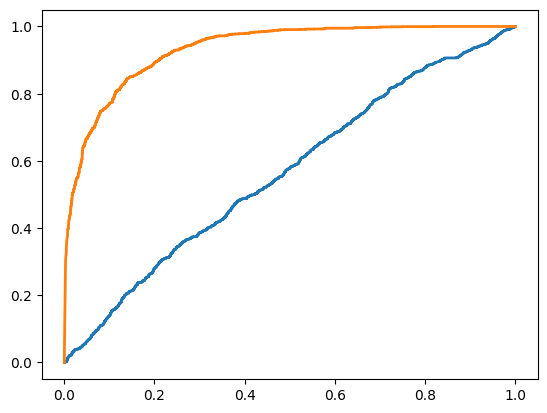

In [ ]:
models = {
    'Dense Neural Network': dense_model,
    'Convolutional Neural Network': cnn_model,
    'LSTM Neural Network': lstm_model,
    'Hybrid CNN-LSTM Neural Network': hybrid_model
}
draw_ROC_curves(X_test, y_test, models, ' With Sentiment Analysis')

##TF-IDF Vectorizer

In [52]:
df_processed = pd.read_csv("Mental-Health-Twitter-Processed.csv").drop_duplicates(subset='post_id')
df_processed = df_processed.dropna()
df_processed = df_processed.sample(frac=1).reset_index(drop=True)
df_processed.rename(columns={'label': 'is_depressed'}, inplace=True)
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed
0,670244616055189504,Fri Nov 27 14:15:43 +0000 2015,think agre help think view challeng debat,47622202,1324,2361,3692,5129,0,1
1,669009617020579840,Tue Nov 24 04:28:16 +0000 2015,brisonaintshiit felt live houston east texan k...,377696171,1035,306,19320,32925,0,1
2,814513504627503104,Thu Dec 29 16:48:47 +0000 2016,wait actual famili albino wait wait idea,490044008,1849,561,8229,86352,0,0
3,653397501127471104,Mon Oct 12 02:31:18 +0000 2015,sound good feel good sgfg,468753088,434,459,17720,6529,0,1
4,648278152989515776,Sun Sep 27 23:28:50 +0000 2015,rememb much yesterday pictur weekend,343501537,1383,1029,32804,14827,0,1
...,...,...,...,...,...,...,...,...,...,...
19790,592950053205057536,Tue Apr 28 07:14:43 +0000 2015,sunshin avenu maximilian schell oscar actor yo...,1616997456,476,1235,0,21533,0,1
19791,814478684325187584,Thu Dec 29 14:30:25 +0000 2016,helen catherina hahaha alright thank input,490044008,1849,561,8229,86352,0,0
19792,817543560216113154,Sat Jan 07 01:29:08 +0000 2017,come soon wearetexan nflplayoff,1497350173,640,445,24297,52892,185,0
19793,670839939257397249,Sun Nov 29 05:41:19 +0000 2015,unless drunk pretti unpredict sorri first impress,377696171,1035,306,19320,32925,0,1


In [53]:
df_sentiment = sentiment_analysis(df_processed['post_id'].to_list(), df_processed['post_text'].to_list())
df_sentiment

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
<ipython-input-48-457908560768>:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sentiment = pd.concat([df_sentiment, new_entry], ignore_index=True)


,post_id,sentiment_score
0,670244616055189504,0.4019
1,669009617020579840,0.0000
2,814513504627503104,0.0000
3,653397501127471104,0.7003
4,648278152989515776,0.0000
...,...,...
19790,592950053205057536,0.0000
19791,814478684325187584,0.7964
19792,817543560216113154,0.0000
19793,670839939257397249,0.1280


In [54]:
df_processed = pd.merge(df_processed, df_sentiment, on='post_id', how='inner')
#df_processed = df_processed.drop_duplicates()
df_processed

,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,is_depressed,sentiment_score
0,670244616055189504,Fri Nov 27 14:15:43 +0000 2015,think agre help think view challeng debat,47622202,1324,2361,3692,5129,0,1,0.4019
1,669009617020579840,Tue Nov 24 04:28:16 +0000 2015,brisonaintshiit felt live houston east texan k...,377696171,1035,306,19320,32925,0,1,0.0000
2,814513504627503104,Thu Dec 29 16:48:47 +0000 2016,wait actual famili albino wait wait idea,490044008,1849,561,8229,86352,0,0,0.0000
3,653397501127471104,Mon Oct 12 02:31:18 +0000 2015,sound good feel good sgfg,468753088,434,459,17720,6529,0,1,0.7003
4,648278152989515776,Sun Sep 27 23:28:50 +0000 2015,rememb much yesterday pictur weekend,343501537,1383,1029,32804,14827,0,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
19790,592950053205057536,Tue Apr 28 07:14:43 +0000 2015,sunshin avenu maximilian schell oscar actor yo...,1616997456,476,1235,0,21533,0,1,0.0000
19791,814478684325187584,Thu Dec 29 14:30:25 +0000 2016,helen catherina hahaha alright thank input,490044008,1849,561,8229,86352,0,0,0.7964
19792,817543560216113154,Sat Jan 07 01:29:08 +0000 2017,come soon wearetexan nflplayoff,1497350173,640,445,24297,52892,185,0,0.0000
19793,670839939257397249,Sun Nov 29 05:41:19 +0000 2015,unless drunk pretti unpredict sorri first impress,377696171,1035,306,19320,32925,0,1,0.1280


In [55]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer to the data and transform the tweets into a TF-IDF representation
tfidf_matrix = tfidf_vectorizer.fit_transform(df_processed['post_text'].to_list())

# Get the list of feature names (words)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Print the TF-IDF matrix
print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

TF-IDF Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [56]:
print(np.all(tfidf_matrix.toarray() == 0))

False


In [57]:
df_processed['post_text'] = list(tfidf_matrix.toarray())
df_processed = df_processed.drop(['followers', 'friends', 'favourites', 'statuses', 'retweets', 'user_id', 'post_created'], axis=1)
df_processed

,post_id,post_text,is_depressed,sentiment_score
0,670244616055189504,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.4019
1,669009617020579840,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0000
2,814513504627503104,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0000
3,653397501127471104,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.7003
4,648278152989515776,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0000
...,...,...,...,...
19790,592950053205057536,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.0000
19791,814478684325187584,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.7964
19792,817543560216113154,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.0000
19793,670839939257397249,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,0.1280


In [58]:
df_post_text_final = pd.DataFrame(df_processed['post_text'].to_list(), columns=tfidf_feature_names)
df_post_text_final['post_id'] = df_processed['post_id']
df_post_text_final['sentiment_score'] = df_processed['sentiment_score']
df_post_text_final

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,post_id,sentiment_score
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,670244616055189504,0.4019
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,669009617020579840,0.0000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,814513504627503104,0.0000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,653397501127471104,0.7003
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,648278152989515776,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,592950053205057536,0.0000
19791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,814478684325187584,0.7964
19792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,817543560216113154,0.0000
19793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,670839939257397249,0.1280


In [59]:
#NEW CODE
df_processed = df_processed.sort_values(by='post_id', ascending=False).reset_index()
df_processed = df_processed.drop('index', axis=1)

df_post_text_final = df_post_text_final.sort_values(by='post_id', ascending=False).reset_index()
df_post_text_final = df_post_text_final.drop('index', axis=1)

df_post_text_final['is_depressed'] = df_processed['is_depressed']
df_processed = df_post_text_final.drop('post_id', axis=1)
df_processed = df_processed.drop('level_0', axis=1)
#df_processed = df_processed.drop_duplicates()
df_processed

,aaron,aaroncarpent,aartoria,abandon,abbi,abil,abl,abort,abroad,absenc,...,zesti,zimmermann,zink,znati,zombi,zone,zquad,zurab,sentiment_score,is_depressed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0516,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.3818,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0772,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7650,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,1
19791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4019,1
19792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,1
19793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,1


In [60]:
print(df_processed.isnull().sum())

aaron              0
aaroncarpent       0
aartoria           0
abandon            0
abbi               0
                  ..
zone               0
zquad              0
zurab              0
sentiment_score    0
is_depressed       0
Length: 5001, dtype: int64


In [61]:
X = df_processed.drop('is_depressed', axis=1)
y = df_processed['is_depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Naive Bayes

In [62]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train, y_train)

# Predict on the test set (ensure X_test is also a dense matrix)
y_pred = gnb_classifier.predict(X_test)

# Evaluate the classifier

accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  82.92498105582217 %
Precision: 78.14798788403289 %
Recall (Sensitivity): 91.350531107739 %
Specificity: 74.52068617558022 %
F1-score: 84.23507462686567 %
              precision    recall  f1-score   support

           0       0.90      0.75      0.81      1982
           1       0.78      0.91      0.84      1977

    accuracy                           0.83      3959
   macro avg       0.84      0.83      0.83      3959
weighted avg       0.84      0.83      0.83      3959

True Positives: 1806
True Negatives: 1477
False Positives: 505
False Negatives: 171


In [63]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
auc_nb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_nb)

ROC-AUC Score: 0.8293560864165961


###Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [65]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.6814852235413 %
Precision: 79.89445910290237 %
Recall (Sensitivity): 76.58067779463835 %
Specificity: 80.77699293642785 %
F1-score: 78.20247933884296 %
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1982
           1       0.80      0.77      0.78      1977

    accuracy                           0.79      3959
   macro avg       0.79      0.79      0.79      3959
weighted avg       0.79      0.79      0.79      3959

True Positives: 1514
True Negatives: 1601
False Positives: 381
False Negatives: 463


In [66]:
auc_dt = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_dt)

ROC-AUC Score: 0.786788353655331


###Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [68]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  81.78833038646123 %
Precision: 82.4045407636739 %
Recall (Sensitivity): 80.77895801719778 %
Specificity: 82.79515640766903 %
F1-score: 81.58365261813539 %
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1982
           1       0.82      0.81      0.82      1977

    accuracy                           0.82      3959
   macro avg       0.82      0.82      0.82      3959
weighted avg       0.82      0.82      0.82      3959

True Positives: 1597
True Negatives: 1641
False Positives: 341
False Negatives: 380


In [69]:
auc_rf = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_rf)

ROC-AUC Score: 0.817870572124334


###Extra Trees

In [70]:
from sklearn.ensemble import ExtraTreesClassifier

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [71]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  82.97549886334933 %
Precision: 82.14109521460287 %
Recall (Sensitivity): 84.2185128983308 %
Specificity: 81.73562058526741 %
F1-score: 83.16683316683317 %
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1982
           1       0.82      0.84      0.83      1977

    accuracy                           0.83      3959
   macro avg       0.83      0.83      0.83      3959
weighted avg       0.83      0.83      0.83      3959

True Positives: 1665
True Negatives: 1620
False Positives: 362
False Negatives: 312


In [72]:
auc_et = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_et)

ROC-AUC Score: 0.8297706674179911


###AdaBoost

In [73]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# Train the classifier
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)

In [74]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  69.76509219499873 %
Precision: 62.51604621309371 %
Recall (Sensitivity): 98.53313100657563 %
Specificity: 41.06962663975782 %
F1-score: 76.49715295503633 %
              precision    recall  f1-score   support

           0       0.97      0.41      0.58      1982
           1       0.63      0.99      0.76      1977

    accuracy                           0.70      3959
   macro avg       0.80      0.70      0.67      3959
weighted avg       0.80      0.70      0.67      3959

True Positives: 1948
True Negatives: 814
False Positives: 1168
False Negatives: 29


In [75]:
auc_ab = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_ab)

ROC-AUC Score: 0.6980137882316673


###Stochastic Gradient Boost

In [76]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the classifier with desired parameters
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=5, subsample=0.8, random_state=42)

# Train the classifier
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)

In [77]:
accuracy, precision, recall, specificity, f1 = calculate_evaluation_metrics(y_pred, y_test)

print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

Accuracy:  78.17630714826976 %
Precision: 82.33585124927367 %
Recall (Sensitivity): 71.67425392008093 %
Specificity: 84.6619576185671 %
F1-score: 76.63601946998378 %
              precision    recall  f1-score   support

           0       0.75      0.85      0.80      1982
           1       0.82      0.72      0.77      1977

    accuracy                           0.78      3959
   macro avg       0.79      0.78      0.78      3959
weighted avg       0.79      0.78      0.78      3959

True Positives: 1417
True Negatives: 1678
False Positives: 304
False Negatives: 560


In [78]:
auc_sgb = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", auc_sgb)

ROC-AUC Score: 0.7816810576932403


model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


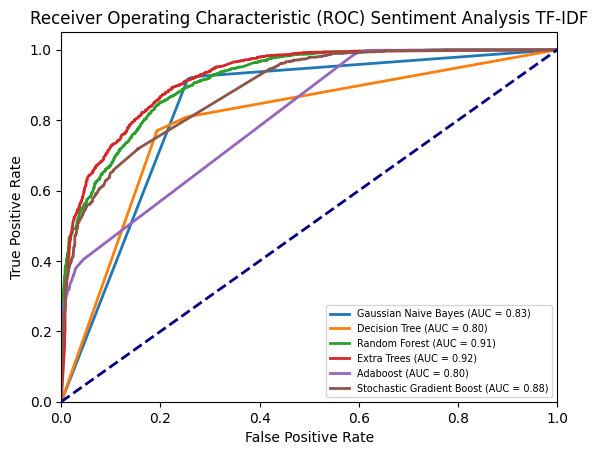

In [ ]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves(X_test, y_test, models, ' Sentiment Analysis TF-IDF')

model =  Gaussian Naive Bayes
model =  Decision Tree
model =  Random Forest
model =  Extra Trees
model =  Adaboost
model =  Stochastic Gradient Boost


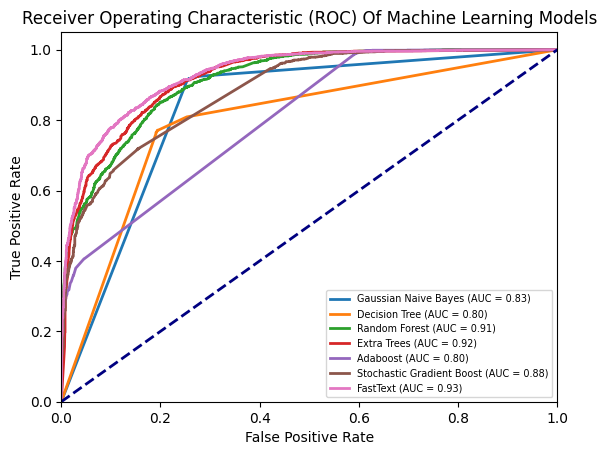

In [85]:
models = {
    'Gaussian Naive Bayes': gnb_classifier,
    'Decision Tree': classifier,
    'Random Forest': rf_model,
    'Extra Trees': clf,
    'Adaboost': ada_clf,
    'Stochastic Gradient Boost': gbc
}
draw_ROC_curves_with_FastText(X_test, y_test, models, fpr_fasttext, tpr_fasttext, fasttext_auc)